In [ ]:
import torch
import numpy as np
import torchvision
import torch.optim as optim
import matplotlib.pyplot as plt
import memtorch
from memtorch.bh.memristor.VTEAM import VTEAM
from memtorch.bh.crossbar import Crossbar
from memtorch.bh.crossbar import Scheme
from memtorch.mn.Module import patch_model
# from memtorch.bh.crossbar.parameter import Parameters
from memtorch.bh.nonideality.NonIdeality import apply_nonidealities
from memtorch.map.Parameter import naive_map
from memtorch.map.Input import naive_scale
import random

In [2]:
class SelfHealingCrossbar:
    """
    Self-healing memristive crossbar that works with MemTorch's implementation.
    Uses a simpler, more compatible approach for redundancy management.
    """
    
    def __init__(self, memristor_model=VTEAM, shape=(128, 128), redundancy_factor=0.1, tile_shape=None):
        """
        Initialize a self-healing crossbar with built-in redundancy.
        
        Args:
            memristor_model: MemTorch memristor model to use
            shape: Crossbar dimensions (rows, cols)
            redundancy_factor: Percentage of redundant devices (0.1 = 10%)
        """
        # Store original dimensions
        self.original_shape = shape
        self.redundancy_factor = redundancy_factor
        
        self.is_remapped = torch.zeros(self.original_shape, dtype=torch.bool)
        self.device_mapping = torch.zeros(self.original_shape, dtype=torch.long)
        
        # Calculate effective shape with redundancy
        effective_rows = int(shape[0] * (1 + redundancy_factor))
        effective_cols = int(shape[1] * (1 + redundancy_factor))
        self.effective_shape = (effective_rows, effective_cols)
        
        # Initialize tracking of which devices are redundant vs primary
        self.is_redundant = torch.zeros(self.effective_shape, dtype=torch.bool)
        self.is_redundant[shape[0]:, :] = True  # Rows beyond original are redundant
        self.is_redundant[:, shape[1]:] = True  # Columns beyond original are redundant
        
        # Track remapped devices (logical device -> physical device mapping)
        self.remapping = {}  # (logical_row, logical_col) -> (physical_row, physical_col)
        
        # Keep track of available redundant devices
        self.available_redundant = []
        for i in range(self.effective_shape[0]):
            for j in range(self.effective_shape[1]):
                if self.is_redundant[i, j]:
                    self.available_redundant.append((i, j))
        
        # Initialize memristor parameters with safe defaults from the documentation
        memristor_params = {
            'r_on': 100,      # Low resistance state (Ohms)
            'r_off': 10000,   # High resistance state (Ohms)
            'time_series_resolution': 1e-10  # Required parameter
        }
        
        # Add model-specific parameters if VTEAM
        if memristor_model.__name__ == 'VTEAM':
            memristor_params.update({
                'd': 3e-9,        # Device length (m)
                'k_on': -10,      # k_on parameter
                'k_off': 5e-4,    # k_off parameter
                'alpha_on': 3,    # alpha_on parameter
                'alpha_off': 1,   # alpha_off parameter
                'v_on': -0.2,     # Positive write threshold voltage (V)
                'v_off': 0.02,    # Negative write threshold voltage (V)
                'x_on': 0,        # x_on parameter
                'x_off': 3e-9,    # x_off parameter
            })
        
        # Initialize the crossbar using MemTorch
        self.crossbar = Crossbar(
            memristor_model=memristor_model,
            memristor_model_params=memristor_params, 
            shape=self.effective_shape,
            tile_shape=tile_shape
        )
        
        # Track health metrics without assuming internal properties
        self.r_on = memristor_params['r_on']
        self.r_off = memristor_params['r_off']
        self.g_min = 1.0 / self.r_off
        self.g_max = 1.0 / self.r_on
        
        # Statistics tracking
        self.mitigation_count = 0
        self.remapping_count = 0
        self.operation_count = 0
        
        print(f"Created self-healing crossbar with shape {shape} and {len(self.available_redundant)} redundant devices")
    
    def _map_logical_to_physical(self, logical_row, logical_col):
        """Maps logical (original) coordinates to physical (effective) coordinates."""
        if logical_row >= self.original_shape[0] or logical_col >= self.original_shape[1]:
            raise ValueError(f"Logical coordinates ({logical_row},{logical_col}) out of bounds")
        
        logical_pos = (logical_row, logical_col)
        if logical_pos in self.remapping:
            # This device has been remapped
            return self.remapping[logical_pos]
        else:
            # Not remapped, use the same coordinates
            return logical_row, logical_col
    
    def write_conductance_matrix(self, conductance_matrix):
        """
        Write a conductance matrix to the crossbar, accounting for any remapped devices.
        
        Args:
            conductance_matrix: Conductance matrix to write (shape should match original_shape)
        """
        if conductance_matrix.shape != self.original_shape:
            # Handle the shape mismatch more gracefully
            if conductance_matrix.numel() == self.original_shape[0] * self.original_shape[1]:
                # Reshape if same number of elements
                conductance_matrix = conductance_matrix.reshape(self.original_shape)
            else:
                raise ValueError(f"Expected conductance matrix of shape {self.original_shape}, got {conductance_matrix.shape}")
        
        # Create a full conductance matrix for the crossbar, initialized with zeros
        effective_conductance = torch.zeros(self.effective_shape)
        
        # Copy the original values to their appropriate location with bounds checking
        for i in range(self.original_shape[0]):
            for j in range(self.original_shape[1]):
                try:
                    physical_row, physical_col = self._map_logical_to_physical(i, j)
                    effective_conductance[physical_row, physical_col] = conductance_matrix[i, j]
                except (IndexError, ValueError) as e:
                    print(f"Warning: Error mapping ({i},{j}): {e}")
        
        # Write to the crossbar with error handling
        try:
            self.crossbar.write_conductance_matrix(effective_conductance)
            self.operation_count += 1
        except Exception as e:
            print(f"Error writing to crossbar: {e}")
    
    def read_conductance_matrix(self):
        """
        Read the conductance matrix from the crossbar, accounting for remapped devices.
        
        Returns:
            Conductance matrix with original dimensions
        """
        # Get the full conductance matrix from the crossbar
        full_conductance = self.crossbar.conductance_matrix
        
        # Create a matrix to hold the logical values
        logical_conductance = torch.zeros(self.original_shape)
        
        # Copy values from their physical positions to logical positions
        for i in range(self.original_shape[0]):
            for j in range(self.original_shape[1]):
                logical_pos = (i, j)
                
                physical_row, physical_col = self._map_logical_to_physical(i, j)
                
                # Get the conductance value from the physical position
                logical_conductance[i, j] = full_conductance[physical_row, physical_col]
        
        return logical_conductance
    
    def simulate_matmul(self, input_tensor):
        """
        Perform matrix multiplication, taking remapping into account.
        
        Args:
            input_tensor: Input tensor for the multiplication
            
        Returns:
            Output tensor from the matrix multiplication
        """
        # Check dimensions
        if input_tensor.shape[1] != self.original_shape[0]:
            raise ValueError(f"Input shape mismatch: expected {self.original_shape[0]}, got {input_tensor.shape[1]}")
        
        # Create input tensor with extended dimensions to account for redundant rows
        extended_input = torch.zeros((input_tensor.shape[0], self.effective_shape[0]))
        
        # Copy the original inputs to their correct positions
        for i in range(self.original_shape[0]):
            # Find all logical positions that map to this input row
            extended_input[:, i] = input_tensor[:, i]
            
            # Check for any remappings from this row to redundant rows
            for j in range(self.original_shape[1]):
                logical_pos = (i, j)
                if logical_pos in self.remapping:
                    physical_row, _ = self._map_logical_to_physical(i, j)
                    if physical_row >= self.original_shape[0]:  # If remapped to redundant row
                        extended_input[:, physical_row] = input_tensor[:, i]
        
        # Perform matrix multiplication
        full_output = self.crossbar.simulate_matmul(input=extended_input)
        
        # Extract only the relevant columns, accounting for remapping
        output = torch.zeros((input_tensor.shape[0], self.original_shape[1]))
        
        # Copy values from physical to logical positions
        for j in range(self.original_shape[1]):
            column_mapped = False
            
            # Check if any logical position has been remapped to a redundant column
            for i in range(self.original_shape[0]):
                logical_pos = (i, j)
                if logical_pos in self.remapping:
                    _, physical_col = self._map_logical_to_physical(i, j)
                    if physical_col >= self.original_shape[1]:  # If remapped to redundant column
                        output[:, j] = full_output[:, physical_col]
                        column_mapped = True
                        break
            
            # If not remapped, use the original column
            if not column_mapped:
                output[:, j] = full_output[:, j]
        
        self.operation_count += 1
        return output
    
    def remap_device(self, logical_row, logical_col):
        """
        Remap a device to an available redundant device.
        
        Args:
            logical_row: Row of the device to remap
            logical_col: Column of the device to remap
            
        Returns:
            True if remapping successful, False otherwise
        """
        logical_pos = (logical_row, logical_col)
        
        # Check if already remapped
        if logical_pos in self.remapping:
            return False
        
        # Check if we have redundant devices available
        if not self.available_redundant:
            return False
        
        # Get current conductance
        full_conductance = self.crossbar.conductance_matrix
        current_conductance = full_conductance[logical_row, logical_col]
        
        # Get an available redundant device
        physical_row, physical_col = self.available_redundant.pop(0)
        
        # Update mapping
        self.remapping[logical_pos] = (physical_row, physical_col)
        
        # Copy conductance to the redundant device
        self.crossbar.conductance_matrix[physical_row, physical_col] = current_conductance
        
        self.remapping_count += 1
        return True
    
    def inject_faults(self, lrs_proportion=0.01, hrs_proportion=0.01):
        """
        Inject stuck-at faults into the crossbar for testing.
        
        Args:
            lrs_proportion: Proportion of devices to make stuck at LRS
            hrs_proportion: Proportion of devices to make stuck at HRS
            
        Returns:
            Number of faults injected
        """
        # Get original crossbar size
        rows, cols = self.original_shape
        total_devices = rows * cols
        
        # Calculate number of devices to make stuck
        num_lrs_faults = int(lrs_proportion * total_devices)
        num_hrs_faults = int(hrs_proportion * total_devices)
        
        # Create random indices for stuck devices
        device_indices = torch.randperm(total_devices)
        lrs_indices = device_indices[:num_lrs_faults]
        hrs_indices = device_indices[num_lrs_faults:num_lrs_faults+num_hrs_faults]
        
        # Apply faults
        faults_injected = 0
        
        for idx in lrs_indices:
            row = idx // cols
            col = idx % cols
            
            # Skip already remapped devices
            if (row, col) in self.remapping:
                continue
                
            # Make device stuck at LRS
            self.crossbar.conductance_matrix[row, col] = self.g_max
            faults_injected += 1
        
        for idx in hrs_indices:
            row = idx // cols
            col = idx % cols
            
            # Skip already remapped devices
            if (row, col) in self.remapping:
                continue
                
            # Make device stuck at HRS
            self.crossbar.conductance_matrix[row, col] = self.g_min
            faults_injected += 1
        
        print(f"Injected {faults_injected} faults ({num_lrs_faults} LRS, {num_hrs_faults} HRS)")
        return faults_injected
    
    def detect_faults(self, threshold=0.1):
        """
        Detect potential faults in the crossbar based on extreme conductance values.
        
        Args:
            threshold: How close to g_min or g_max to consider a fault
            
        Returns:
            List of detected faults as (row, col) tuples
        """
        # Get current conductance matrix
        conductance = self.crossbar.conductance_matrix
        
        # Define thresholds for detecting stuck devices
        g_min_threshold = self.g_min + threshold * (self.g_max - self.g_min)
        g_max_threshold = self.g_max - threshold * (self.g_max - self.g_min)
        
        # Find potential faults
        faults = []
        
        for i in range(self.original_shape[0]):
            for j in range(self.original_shape[1]):
                # Skip already remapped devices
                if (i, j) in self.remapping:
                    continue
                
                g_value = conductance[i, j]
                
                # Check if device appears stuck
                if g_value <= g_min_threshold or g_value >= g_max_threshold:
                    faults.append((i, j))
        
        return faults
    
    def apply_self_healing(self):
        """
        Apply self-healing by detecting and remapping faulty devices.
        
        Returns:
            Number of devices healed
        """
        # Skip if no redundant devices available
        if not self.available_redundant:
            return 0
        
        # Detect potential faults
        faults = self.detect_faults()
        if not faults:
            return 0
        
        # Apply remapping to as many faults as possible
        healed_count = 0
        
        for row, col in faults:
            if healed_count >= len(self.available_redundant):
                break
                
            if self.remap_device(row, col):
                healed_count += 1
        
        self.mitigation_count += healed_count
        print(f"Healed {healed_count} devices. Total remapped: {self.remapping_count}")
        
        return healed_count

In [3]:
class HealthMonitor:
    """
    Comprehensive health monitoring and prediction system for memristive crossbars.
    Combines features from MemristorHealthMonitor and MemristorHealthPredictor.
    """
    
    def __init__(self, crossbar):
        """Initialize the enhanced health monitor."""
        self.crossbar = crossbar
        self.shape = crossbar.conductance_matrix.shape
        
        # Extract device parameters
        try:
            # Try direct access first
            self.r_on = getattr(crossbar, 'r_on', None)
            self.r_off = getattr(crossbar, 'r_off', None)
            
            # If not available, try through memristor_model_params
            if self.r_on is None and hasattr(crossbar, 'memristor_model_params'):
                self.r_on = crossbar.memristor_model_params.get('r_on', 100)
                self.r_off = crossbar.memristor_model_params.get('r_off', 16000.0)
            
            # Fall back to defaults if necessary
            self.r_on = self.r_on if self.r_on is not None else 100
            self.r_off = self.r_off if self.r_off is not None else 16000.0
        except Exception:
            # Fallback to defaults
            self.r_on = 100
            self.r_off = 16000.0
        
        # Derived properties
        self.g_min = 1.0 / self.r_off
        self.g_max = 1.0 / self.r_on
        self.g_mid = (self.g_max + self.g_min) / 2
        self.g_range = self.g_max - self.g_min
        
        # Health tracking metrics
        self.stress = torch.zeros(self.shape)
        self.health_scores = torch.ones(self.shape) * 100
        self.write_count = torch.zeros(self.shape)
        self.read_count = torch.zeros(self.shape)
        self.stability_index = torch.ones(self.shape)
        self.operation_counts = torch.zeros(self.shape)
        
        # History tracking for predictive analytics
        self.g_history = [crossbar.conductance_matrix.clone()]
        self.max_history = 20
        
        # Fault prediction parameters
        self.failure_probability = torch.zeros(self.shape)
        self.failure_threshold = 0.8
        
        print(f"Initialized enhanced health monitor for {self.shape[0]}x{self.shape[1]} crossbar")
    
    def update_health_metrics(self, voltage_applied=None, write_op=False):
        """Update health metrics based on recent operations and current state."""
        current_g = self.crossbar.conductance_matrix
        
        # Update operation counters
        if write_op:
            self.write_count += torch.ones(self.shape)
        else:
            self.read_count += torch.ones(self.shape)
            
        self.operation_counts += 1
        
        # Calculate normalized conductance and deviation from ideal
        g_normalized = (current_g - self.g_min) / self.g_range
        g_normalized = torch.clamp(g_normalized, 0, 1)
        deviation_from_mid = 2 * torch.abs(g_normalized - 0.5)
        
        # Calculate stability metrics if we have history
        if len(self.g_history) >= 3:
            prev_g1 = self.g_history[-1]
            prev_g2 = self.g_history[-2]
            
            # Compute changes
            recent_change1 = torch.abs(current_g - prev_g1) / self.g_range
            recent_change2 = torch.abs(prev_g1 - prev_g2) / self.g_range
            
            # Compute accelerations
            change_acceleration = torch.abs(recent_change1 - recent_change2)
            
            # Update stability index - lower means less stable
            self.stability_index = self.stability_index * 0.9 + (1.0 - change_acceleration * 10) * 0.1
            self.stability_index = torch.clamp(self.stability_index, 0.0, 1.0)
            
            # Large changes indicate instability
            unstable = recent_change1 > 0.1
            self.health_scores[unstable] -= 0.5  # Additional penalty
        
        # Calculate stress from operation
        op_stress_factor = 0.02 if write_op else 0.001
        voltage_factor = 1.0
        
        if voltage_applied is not None:
            max_voltage = self.crossbar.max_voltage if hasattr(self.crossbar, 'max_voltage') else 1.0
            voltage_normalized = torch.abs(voltage_applied) / max_voltage
            voltage_factor = 1.0 + voltage_normalized
        
        # New stress from this operation
        new_stress = op_stress_factor * voltage_factor * (0.5 + deviation_from_mid)
        
        # Stress increases for unstable devices
        new_stress = new_stress * (2.0 - self.stability_index)
        
        # Update accumulated stress (with partial decay over time)
        self.stress = self.stress * 0.99 + new_stress
        self.stress = torch.clamp(self.stress, 0.0, 1.0)
        
        # Update health scores
        self.health_scores = 100 * (1.0 - self.stress)
        self.health_scores = torch.clamp(self.health_scores, 0, 100)
        
        # Store current state in history
        self.g_history.append(current_g.clone())
        if len(self.g_history) > self.max_history:
            self.g_history.pop(0)
    
    def predict_faults(self):
        """Predict which devices are likely to fail soon."""
        # 1. Extreme conductance values indicate potential issues
        g_normalized = (self.crossbar.conductance_matrix - self.g_min) / self.g_range
        g_normalized = torch.clamp(g_normalized, 0, 1)
        proximity_to_extreme = torch.max(
            4 * torch.pow(g_normalized, 2),
            4 * torch.pow(1 - g_normalized, 2)
        )
        proximity_to_extreme = torch.clamp(proximity_to_extreme, 0.0, 1.0)
        
        # 2. Instability is a strong predictor of failure
        instability_factor = 1.0 - self.stability_index
        
        # 3. Recent conductance drift trend
        drift_factor = torch.zeros(self.shape)
        if len(self.g_history) >= 5:
            g_diffs = []
            for i in range(1, min(5, len(self.g_history))):
                g_diff = (self.g_history[-i] - self.g_history[-i-1]) / self.g_range
                g_diffs.append(g_diff)
            
            g_diffs_tensor = torch.stack(g_diffs)
            drift_magnitude = torch.mean(torch.abs(g_diffs_tensor), dim=0)
            drift_consistency = torch.std(torch.sign(g_diffs_tensor), dim=0)
            
            drift_factor = drift_magnitude * (2.0 - drift_consistency)
            drift_factor = torch.clamp(drift_factor * 5.0, 0.0, 1.0)
        
        # 4. Stress history (accumulated wear)
        stress_factor = self.stress
        
        # Combine factors with weights to get failure probability
        self.failure_probability = (
            0.4 * stress_factor +
            0.3 * instability_factor +
            0.2 * proximity_to_extreme +
            0.1 * drift_factor
        )
        
        return self.failure_probability
    
    def get_critical_devices(self, health_threshold=10, probability_threshold=0.8, extreme_threshold=0.02):
        """Get devices in critical condition that should be prioritized for healing."""
        # Run prediction to update failure probabilities
        self.predict_faults()
        
        # Get current conductance
        current_g = self.crossbar.conductance_matrix
        g_normalized = (current_g - self.g_min) / self.g_range
        g_normalized = torch.clamp(g_normalized, 0, 1)
        
        # Find critical devices
        critical_devices = []
        
        for i in range(self.shape[0]):
            for j in range(self.shape[1]):
                # Check all criteria
                if (self.health_scores[i, j] < health_threshold or
                    self.failure_probability[i, j] > probability_threshold or
                    g_normalized[i, j] < extreme_threshold or 
                    g_normalized[i, j] > (1 - extreme_threshold)):
                    critical_devices.append((i, j))
        
        return critical_devices
    
    def get_health_summary(self):
        """Get a comprehensive health report."""
        # Run prediction to ensure up-to-date values
        self.predict_faults()
        
        # Calculate failure categories
        imminent_failures = (self.failure_probability > 0.8)
        upcoming_failures = (self.failure_probability > 0.5) & (self.failure_probability <= 0.8)
        at_risk_devices = (self.failure_probability > 0.3) & (self.failure_probability <= 0.5)
        
        # Count devices in each category
        imminent_count = imminent_failures.sum().item()
        upcoming_count = upcoming_failures.sum().item()
        at_risk_count = at_risk_devices.sum().item()
        total_devices = self.shape[0] * self.shape[1]
        
        # Calculate average values
        avg_health = self.health_scores.mean().item()
        min_health = self.health_scores.min().item()
        avg_stability = self.stability_index.mean().item()
        avg_failure_prob = self.failure_probability.mean().item()
        
        # Check for stuck devices
        g_values = self.crossbar.conductance_matrix
        g_normalized = (g_values - self.g_min) / self.g_range
        
        stuck_at_min = (g_normalized < 0.05).sum().item()
        stuck_at_max = (g_normalized > 0.95).sum().item()
        
        return {
            'avg_health': avg_health,
            'min_health': min_health,
            'avg_stability': avg_stability,
            'avg_failure_prob': avg_failure_prob,
            'imminent_failures': imminent_count,
            'imminent_percent': 100 * imminent_count / total_devices,
            'upcoming_failures': upcoming_count,
            'upcoming_percent': 100 * upcoming_count / total_devices,
            'at_risk_count': at_risk_count,
            'at_risk_percent': 100 * at_risk_count / total_devices,
            'total_at_risk': imminent_count + upcoming_count + at_risk_count,
            'total_at_risk_percent': 100 * (imminent_count + upcoming_count + at_risk_count) / total_devices,
            'stuck_at_min': stuck_at_min,
            'stuck_at_max': stuck_at_max,
            'total_stuck': stuck_at_min + stuck_at_max,
            'stuck_percent': 100 * (stuck_at_min + stuck_at_max) / total_devices,
            'critical_count': (self.health_scores < 20).sum().item(),
            'total_operations': self.operation_counts.mean().item()
        }
    
    def visualize_health(self):
        """Visualize health metrics in a comprehensive dashboard."""
        # Update failure probabilities
        self.predict_faults()
        
        # Create figure with multiple subplots
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Health scores
        im1 = axes[0, 0].imshow(self.health_scores.numpy(), cmap='RdYlGn', vmin=0, vmax=100)
        axes[0, 0].set_title('Health Scores')
        fig.colorbar(im1, ax=axes[0, 0])
        
        # 2. Stability index
        im2 = axes[0, 1].imshow(self.stability_index.numpy(), cmap='coolwarm', vmin=0, vmax=1)
        axes[0, 1].set_title('Stability Index')
        fig.colorbar(im2, ax=axes[0, 1])
        
        # 3. Failure probability
        im3 = axes[1, 0].imshow(self.failure_probability.numpy(), cmap='plasma', vmin=0, vmax=1)
        axes[1, 0].set_title('Failure Probability')
        fig.colorbar(im3, ax=axes[1, 0])
        
        # 4. Current conductance
        g_normalized = ((self.crossbar.conductance_matrix - self.g_min) / self.g_range).numpy()
        im4 = axes[1, 1].imshow(g_normalized, cmap='viridis', vmin=0, vmax=1)
        axes[1, 1].set_title('Normalized Conductance')
        fig.colorbar(im4, ax=axes[1, 1])
        
        plt.tight_layout()
        plt.show()
    
    def visualize_health_and_mapping(self):
        """
        Visualize the health and mapping of devices in the crossbar.
        """
        plt.figure(figsize=(12, 4))
        
        # 1. Show conductance matrix
        plt.subplot(1, 3, 1)
        g_normalized = (self.crossbar.conductance_matrix - self.g_min) / (self.g_max - self.g_min)
        g_normalized = torch.clamp(g_normalized, 0, 1)
        plt.imshow(g_normalized.numpy(), cmap='viridis')
        plt.colorbar(label='Normalized Conductance')
        plt.title('Conductance Values')
        
        # 2. Show remapped devices
        plt.subplot(1, 3, 2)
        remapping_mask = torch.zeros(self.effective_shape)
        
        # Mark original area
        for i in range(self.original_shape[0]):
            for j in range(self.original_shape[1]):
                if (i, j) in self.remapping:
                    physical_row, physical_col = self.remapping[(i, j)]
                    remapping_mask[physical_row, physical_col] = 2  # Remapped destination
                    remapping_mask[i, j] = 1  # Original position (remapped source)
                else:
                    remapping_mask[i, j] = 0.5  # Normal original device
        
        # Mark redundant area
        for i in range(self.effective_shape[0]):
            for j in range(self.effective_shape[1]):
                if self.is_redundant[i, j] and remapping_mask[i, j] == 0:
                    remapping_mask[i, j] = 0.25  # Unused redundant
        
        plt.imshow(remapping_mask.numpy(), cmap='coolwarm')
        plt.colorbar(label='Device Status')
        plt.title('Device Remapping')
        
        # 3. Show health estimate
        plt.subplot(1, 3, 3)
        # Estimate health based on how close conductances are to extremes
        g_normalized = (self.crossbar.conductance_matrix - self.g_min) / (self.g_max - self.g_min)
        g_normalized = torch.clamp(g_normalized, 0, 1)
        deviation = torch.abs(g_normalized - 0.5) * 2
        health_scores = 100 * (1.0 - deviation)
        
        plt.imshow(health_scores.numpy(), cmap='RdYlGn', vmin=0, vmax=100)
        plt.colorbar(label='Health Score')
        plt.title('Estimated Device Health')
        
        plt.tight_layout()
        plt.show()

In [4]:
class SimpleCNN(torch.nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = torch.nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = torch.nn.Linear(32 * 8 * 8, 128)
        self.fc2 = torch.nn.Linear(128, 10)
        self.relu = torch.nn.ReLU()
        self.pool = torch.nn.MaxPool2d(2, 2)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, x):
        """
        Forward pass with safer implementation.
        """
        # Process through CNN layers
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        # If we have a separate memristive model, use it instead
        output = x
        if hasattr(self, 'memristive_model') and self.memristive_model is not self:
            with torch.set_grad_enabled(self.memristive_model.training):
                output = self.memristive_model(x)
                
        # Update stats if tracking is enabled
        if hasattr(self, 'total_operations'):
            self.total_operations += 1
            
            # Periodically check health if implemented
            if hasattr(self, 'check_health') and callable(self.check_health) and self.total_operations % 10 == 0:
                with torch.no_grad():
                    self.check_health()
        
        return output

In [5]:
class EnhancedFaultTolerantNeuromorphic:
    """
    Enhanced fault-tolerant neuromorphic computing system with multiple mitigation strategies:
    1. Soft mitigation (adjusting conductance)
    2. Redundancy-based remapping (using spare devices)
    3. Layer reset (for catastrophic failures)
    """
    
    def __init__(self, base_model=None, memristor_model=VTEAM, redundancy_factor=0.15):
        """
        Initialize the enhanced fault-tolerant neuromorphic system.
        
        Args:
            base_model: Base PyTorch model (if None, creates a SimpleCNN)
            memristor_model: Memristor model to use
            redundancy_factor: Redundancy factor for self-healing crossbars
        """
        
        self.memristive_layers = {}
        self.crossbars = {}
        self.monitors = {}
        
        # Create base model if not provided
        if base_model is None:
            self.base_model = SimpleCNN()
        else:
            self.base_model = base_model
        
        # Define memristor parameters
        memristor_params = {
            'r_on': 100,      # Low resistance state (Ohms)
            'r_off': 10000,   # High resistance state (Ohms)
            'time_series_resolution': 1e-10  # Required parameter
        }
        
        # Add model-specific parameters if using VTEAM
        if memristor_model.__name__ == 'VTEAM':
            memristor_params.update({
                'd': 3e-9,        # Device length (m)
                'k_on': -10,      # k_on parameter
                'k_off': 5e-4,    # k_off parameter
                'alpha_on': 3,    # alpha_on parameter
                'alpha_off': 1,   # alpha_off parameter
                'v_on': -0.2,     # Positive write threshold voltage (V)
                'v_off': 0.02,    # Negative write threshold voltage (V)
                'x_on': 0,        # x_on parameter
                'x_off': 3e-9,    # x_off parameter
            })
        
        # Store for future use
        self.memristor_model = memristor_model
        self.memristor_params = memristor_params
        self.redundancy_factor = redundancy_factor
        
        # Convert to memristive model
        try:
            self.memristive_model = patch_model(
                model=self.base_model,
                memristor_model=memristor_model,
                memristor_model_params=memristor_params,
                module_parameters_to_patch=[torch.nn.Linear],  # Start with just linear layers
                mapping_routine=naive_map,
                transistor=True,
                scheme=Scheme.DoubleColumn,
                max_input_voltage=0.3,
                scaling_routine=naive_scale,
                ADC_resolution=8,
                ADC_overflow_rate=0.0,
                quant_method='linear'
            )
            print("Successfully patched model with memristors")
        except Exception as e:
            print(f"Error patching model: {e}")
            # Fall back to original model
            self.memristive_model = self.base_model
            print("Using original model as fallback")
        
        # Track memristive layers
        self.memristive_layers = {}  # name -> module mapping
        self.health_monitors = {}    # name -> health monitor mapping
        self.self_healing_crossbars = {}  # name -> self-healing crossbar mapping
        
        # Scan for memristive layers and create self-healing replacements
        for name, module in self.memristive_model.named_modules():
            if hasattr(module, 'crossbars'):
                print(f"Found memristive layer: {name}")
                self.memristive_layers[name] = module
                
                # Create health monitors and self-healing replacements for each crossbar
                for i, crossbar in enumerate(module.crossbars):
                    crossbar_name = f"{name}_crossbar_{i}"
                    
                    # Create an enhanced monitor for the original crossbar
                    self.health_monitors[crossbar_name] = HealthMonitor(crossbar)
                    
                    # Create a self-healing crossbar with the same shape
                    crossbar_shape = crossbar.conductance_matrix.shape
                    # SelfHealingCrossbar expects the original shape without redundancy
                    adjusted_shape = (
                        int(crossbar_shape[0] / (1 + redundancy_factor)),
                        int(crossbar_shape[1] / (1 + redundancy_factor))
                    )
                    adjusted_shape = tuple(max(1, dim) for dim in adjusted_shape)  # Ensure at least 1x1

                    self.self_healing_crossbars[crossbar_name] = SelfHealingCrossbar(
                        memristor_model=memristor_model,
                        shape=adjusted_shape,
                        redundancy_factor=redundancy_factor
                    )
        
        # Create backup of original weights for critical situations
        self.original_weights = {}
        for name, module in self.base_model.named_modules():
            if isinstance(module, torch.nn.Linear) or isinstance(module, torch.nn.Conv2d):
                if hasattr(module, 'weight'):
                    self.original_weights[name] = module.weight.data.clone()
        
        # Statistics for all mitigation strategies
        self.total_operations = 0
        self.total_faults_detected = 0
        self.total_soft_mitigations = 0
        self.total_remappings = 0
        self.total_layer_resets = 0
        self.redundant_available = sum(len(sb.available_redundant) for sb in self.self_healing_crossbars.values())
        
        
        if hasattr(self.memristive_model, 'forward_legacy'):
            self.memristive_model.forward_legacy(True)
        
        print(f"Initialized enhanced fault-tolerant system with {len(self.memristive_layers)} memristive layers")
        print(f"Total redundant devices available: {self.redundant_available}")
    
    
    def debug_deepcopy_issue(self):
        """Debug function to identify where deepcopy issues are occurring."""
        print("Testing potential deepcopy issues...")
        
        try:
            print("Testing memristive_model access...")
            model = self.memristive_model
            print("  ✓ Basic model access")
            
            print("Testing model parameters...")
            for name, param in model.named_parameters():
                print(f"  Parameter: {name}, requires_grad: {param.requires_grad}")
            print("  ✓ Model parameters access")
            
            print("Testing forward method...")
            if hasattr(model, 'forward'):
                print("  Model has forward method")
            else:
                print("  Model does not have explicit forward method")
            
            print("Testing a simple forward pass...")
            dummy_input = torch.zeros((1, 3, 32, 32))  # Adjust size to match expected input
            try:
                with torch.no_grad():
                    output = model(dummy_input)
                print("  ✓ Forward pass with torch.no_grad()")
            except Exception as e:
                print(f"  ✗ Forward pass with torch.no_grad() failed: {e}")
            
            print("Testing crossbars access...")
            for name, module in model.named_modules():
                if hasattr(module, 'crossbars'):
                    print(f"  Found crossbars in {name}")
                    for i, crossbar in enumerate(module.crossbars):
                        print(f"    Crossbar {i} shape: {crossbar.conductance_matrix.shape}")
            
            print("Testing health monitors...")
            for name, monitor in self.health_monitors.items():
                print(f"  Monitor: {name}")
                try:
                    with torch.no_grad():
                        metrics = monitor.get_health_summary()
                    print("    ✓ Health summary retrieved")
                except Exception as e:
                    print(f"    ✗ Health summary failed: {e}")
            
            print("All tests completed")
            
        except Exception as e:
            print(f"Debug failed: {e}")
    
    # high-level methods:
    def forward(self, x):
        """Forward pass with fault monitoring."""
        try:
            # Forward pass using the memristive model
            # Use a context manager to properly handle gradient requirements based on mode
            with torch.set_grad_enabled(self.memristive_model.training):
                output = self.memristive_model(x)
            
            # Update stats outside of gradient tracking
            with torch.no_grad():
                self.total_operations += 1
                
                # Periodically check health
                if self.total_operations % 10 == 0:
                    self.check_health()
            
            return output
        
        except RuntimeError as e:
            print("not using health check due to deep copy")
            with torch.set_grad_enabled(self.memristive_model.training):
                output = self.memristive_model(x)
            
            return output
    
    def check_health(
        self,
        health_threshold=40,
        force_remapping=False,
        enable_soft_mitigation=True,
        enable_remapping=True,
        enable_layer_reset=True):
        """
        Check health of all memristive layers and apply tiered mitigation strategies.
        First tries soft mitigation, then remapping, and finally layer reset if necessary.
        
        Returns:
            Number of issues found
        """
        total_issues = 0
        
        if not (enable_soft_mitigation or enable_remapping or enable_layer_reset):
            print("All mitigation strategies are disabled. Performing health monitoring only.")
            
            # Still update health metrics but don't apply any mitigations
            for name, monitor in self.health_monitors.items():
                try:
                    monitor.update_health_metrics()
                    critical_devices = monitor.get_critical_devices()
                    total_issues += len(critical_devices)
                    
                    if critical_devices:
                        layer_health = monitor.get_health_summary()
                        print(f"Found {len(critical_devices)} critical devices in {name} (health: {layer_health['avg_health']:.2f}%)")
                        print(f"No mitigation applied (all strategies disabled)")
                        
                except Exception as e:
                    print(f"Error checking health for {name}: {e}")
                    
            self.total_faults_detected += total_issues
            return total_issues
        
        # Update all health monitors
        for name, monitor in self.health_monitors.items():
            try:
                monitor.update_health_metrics()
                
                # Check for critical devices
                critical_devices = monitor.get_critical_devices()
                total_issues += len(critical_devices)
                
                # Only proceed if there are critical devices or remapping is forced
                if critical_devices or (force_remapping and enable_remapping):
                    if critical_devices:
                        print(f"Found {len(critical_devices)} critical devices in {name}")
                    elif force_remapping and enable_remapping:
                        print(f"Forcing remapping check on {name} (even without critical devices)")
                    
                    # Extract the layer_name and crossbar_idx
                    name_parts = name.split('_crossbar_')
                    layer_name = name_parts[0]
                    crossbar_idx = int(name_parts[1])
                    
                    # Get health metrics
                    layer_health = monitor.get_health_summary()
                    
                    # Now apply enabled mitigation strategies in a well-defined order
                    
                    # CASE 1: Forced remapping (highest priority if enabled)
                    if force_remapping and enable_remapping and critical_devices:
                        print(f"Forcing remapping strategy on {name}")
                        mitigated = self._apply_redundancy_remapping(name, critical_devices)
                        print(f"Remapped {mitigated}/{len(critical_devices)} devices")
                        
                        # Apply soft mitigation to remaining devices only if explicitly enabled
                        if mitigated < len(critical_devices) and enable_soft_mitigation:
                            remaining_devices = critical_devices[mitigated:]
                            print(f"Applying soft mitigation to remaining {len(remaining_devices)} devices")
                            self._apply_soft_mitigation(name, remaining_devices)
                    
                    # CASE 2: Choose strategy based on health (if forced remapping not used)
                    elif critical_devices:
                        # Separate handling for "Remapping Only" case
                        if enable_remapping and not enable_soft_mitigation and not enable_layer_reset:
                            print(f"Using remapping only for {name} (health: {layer_health['avg_health']:.2f}%)")
                            mitigated = self._apply_redundancy_remapping(name, critical_devices)
                            print(f"Remapped {mitigated}/{len(critical_devices)} devices")
                        
                        # Separate handling for "Soft Mitigation Only" case
                        elif enable_soft_mitigation and not enable_remapping and not enable_layer_reset:
                            print(f"Using soft mitigation only for {name} (health: {layer_health['avg_health']:.2f}%)")
                            self._apply_soft_mitigation(name, critical_devices)
                        
                        # Separate handling for "Layer Reset Only" case
                        elif enable_layer_reset and not enable_remapping and not enable_soft_mitigation:
                            print(f"Using layer reset only for {name} (health: {layer_health['avg_health']:.2f}%)")
                            if self.reset_critical_layer(layer_name):
                                self.total_layer_resets += 1
                        
                        # Handle combined strategies with prioritization
                        elif enable_soft_mitigation or enable_remapping or enable_layer_reset:
                            # High health: Use soft mitigation if enabled
                            if layer_health['avg_health'] > health_threshold and enable_soft_mitigation:
                                print(f"Using soft mitigation for {name} (health: {layer_health['avg_health']:.2f}%)")
                                self._apply_soft_mitigation(name, critical_devices)
                            
                            # Medium health: Use remapping if enabled
                            elif layer_health['avg_health'] > health_threshold/2 and enable_remapping:
                                print(f"Using remapping for {name} (health: {layer_health['avg_health']:.2f}%)")
                                mitigated = self._apply_redundancy_remapping(name, critical_devices)
                                
                                # Apply soft mitigation to remaining devices only if explicitly enabled
                                if mitigated < len(critical_devices) and enable_soft_mitigation:
                                    remaining_devices = critical_devices[mitigated:]
                                    print(f"Applying soft mitigation to remaining {len(remaining_devices)} devices")
                                    self._apply_soft_mitigation(name, remaining_devices)
                            
                            # Low health: Use layer reset if enabled
                            elif enable_layer_reset:
                                print(f"Critical health ({layer_health['avg_health']:.2f}%), attempting reset")
                                if self.reset_critical_layer(layer_name):
                                    self.total_layer_resets += 1
                            
                            # If health is too low for soft mitigation and remapping/reset not enabled
                            else:
                                print(f"Health too low for enabled strategies: {layer_health['avg_health']:.2f}%")
                        
                        # This should never happen with the logic above, but just in case:
                        else:
                            print(f"No applicable mitigation strategy for {name} (health: {layer_health['avg_health']:.2f}%)")
                    
            except Exception as e:
                print(f"Error checking health for {name}: {e}")
        
        self.total_faults_detected += total_issues
        return total_issues
    
    # mitigation strategy implementations
    def _apply_soft_mitigation(self, crossbar_name, critical_devices):
        """Apply soft mitigation by adjusting conductance toward middle range."""
        # Extract the layer_name and crossbar_idx
        name_parts = crossbar_name.split('_crossbar_')
        layer_name = name_parts[0]
        crossbar_idx = int(name_parts[1])
        
        if layer_name not in self.memristive_layers:
            return 0
        
        module = self.memristive_layers[layer_name]
        if not hasattr(module, 'crossbars') or crossbar_idx >= len(module.crossbars):
            return 0
        
        crossbar = module.crossbars[crossbar_idx]
        monitor = self.health_monitors[crossbar_name]
        
        # Get mid-range conductance
        g_mid = (monitor.g_min + monitor.g_max) / 2
        
        # Apply soft mitigation by moving conductance toward middle range
        mitigated_count = 0
        for row, col in critical_devices:
            current_g = crossbar.conductance_matrix[row, col]
            # Move 30% of the way toward mid-range
            new_g = current_g * 0.7 + g_mid * 0.3
            crossbar.conductance_matrix[row, col] = new_g
            mitigated_count += 1
        
        self.total_soft_mitigations += mitigated_count
        print(f"Applied soft mitigation to {mitigated_count} devices in {crossbar_name}")
        return mitigated_count
    
    def _apply_redundancy_remapping(self, crossbar_name, critical_devices):
        """
        Properly integrated redundancy-based remapping that works with forward pass.
        """
        # Get the self-healing crossbar for this name
        if crossbar_name not in self.self_healing_crossbars:
            return 0
        
        # Extract the layer_name and crossbar_idx
        name_parts = crossbar_name.split('_crossbar_')
        layer_name = name_parts[0]
        crossbar_idx = int(name_parts[1])
        
        if layer_name not in self.memristive_layers:
            return 0
        
        module = self.memristive_layers[layer_name]
        if not hasattr(module, 'crossbars') or crossbar_idx >= len(module.crossbars):
            return 0
        
        # Get the original crossbar
        original_crossbar = module.crossbars[crossbar_idx]
        
        # Get the self-healing crossbar
        healing_crossbar = self.self_healing_crossbars[crossbar_name]
        
        # Key addition: Check if this crossbar has been integrated
        if not hasattr(healing_crossbar, '_integrated_with_original'):
            print(f"First-time integration of self-healing crossbar for {crossbar_name}")
            
            # Copy original conductance matrix to the self-healing crossbar
            original_shape = healing_crossbar.original_shape
            copy_rows = min(original_crossbar.conductance_matrix.shape[0], original_shape[0])
            copy_cols = min(original_crossbar.conductance_matrix.shape[1], original_shape[1])
            
            # Copy what fits
            conductance_matrix = original_crossbar.conductance_matrix[:copy_rows, :copy_cols].clone()
            
            # Pad if needed
            if conductance_matrix.shape != original_shape:
                padded = torch.zeros(original_shape)
                padded[:conductance_matrix.shape[0], :conductance_matrix.shape[1]] = conductance_matrix
                conductance_matrix = padded
            
            # Initialize the self-healing crossbar
            healing_crossbar.write_conductance_matrix(conductance_matrix)
            
            # ★ CRITICAL FIX: Replace the original crossbar with our self-healing crossbar
            # This ensures the remapping logic is used during forward pass
            module.crossbars[crossbar_idx] = healing_crossbar.crossbar
            
            # Mark that we've integrated this crossbar
            healing_crossbar._integrated_with_original = True
            print(f"Successfully integrated self-healing crossbar into model")
        
        # Now apply remapping to critical devices
        remapped_count = 0
        for row, col in critical_devices:
            if row >= healing_crossbar.original_shape[0] or col >= healing_crossbar.original_shape[1]:
                continue  # Skip if out of bounds for the healing crossbar
            
            # Try to remap this device using the self-healing crossbar's logic
            if healing_crossbar.remap_device(row, col):
                remapped_count += 1
                self.total_remappings += 1
            
            # Stop if we've run out of redundant devices
            if not healing_crossbar.available_redundant:
                break
        
        print(f"Remapped {remapped_count} devices in {crossbar_name} using redundancy")
        
        # Update the count of available redundant devices
        try:
            self.redundant_available = sum(len(sb.available_redundant) for sb in self.self_healing_crossbars.values())
        except Exception as e:
            print(f"Warning: Unable to calculate available redundant devices: {e}")
            self.redundant_available = 0
        
        return remapped_count
    
    def reset_critical_layer(self, layer_name):
        """Reset a critical layer back to its original weights as a last resort."""
        if layer_name not in self.memristive_layers or layer_name not in self.original_weights:
            return False
        
        try:
            # Get the memristive module
            module = self.memristive_layers[layer_name]
            
            # Check if module has weight parameter
            if not hasattr(module, 'weight'):
                return False
            
            # Reset weight to original value
            module.weight.data.copy_(self.original_weights[layer_name])
            
            # If module has crossbars, update them
            if hasattr(module, 'crossbars'):
                # Re-map weights to crossbars (simplistic approach)
                for crossbar in module.crossbars:
                    # This is a simplified approach - in a real implementation, 
                    # you would need to follow the same mapping routine used during initialization
                    crossbar.conductance_matrix.copy_(module.weight.data)
            
            print(f"Reset layer {layer_name} to original weights")
            return True
        
        except Exception as e:
            print(f"Error resetting layer {layer_name}: {e}")
            return False
    
    # utility methods:
    def inject_faults(self, fault_density=0.05, distribution='random'):
        """
        Inject faults into memristive layers for testing.
        
        Args:
            fault_density: Proportion of devices to make faulty
            distribution: How to distribute faults ('random', 'clustered', or 'gradient')
            
        Returns:
            Number of faults injected
        """
        total_faults = 0
        
        # Inject faults into each crossbar
        for name, monitor in self.health_monitors.items():
            try:
                # Get the crossbar
                name_parts = name.split('_crossbar_')
                layer_name = name_parts[0]
                crossbar_idx = int(name_parts[1])
                
                if layer_name not in self.memristive_layers:
                    continue
                
                module = self.memristive_layers[layer_name]
                if not hasattr(module, 'crossbars') or crossbar_idx >= len(module.crossbars):
                    continue
                
                crossbar = module.crossbars[crossbar_idx]
                
                # Get total number of devices
                total_devices = crossbar.conductance_matrix.numel()
                num_faults = int(total_devices * fault_density)
                
                # Distribute faults based on chosen pattern
                if distribution == 'clustered':
                    # Create clustered faults by selecting central points and adding neighbors
                    rows, cols = crossbar.conductance_matrix.shape
                    centers = torch.randperm(total_devices)[:num_faults // 5]  # Select 1/5 as many centers
                    
                    # Convert to coordinates
                    center_rows = centers // cols
                    center_cols = centers % cols
                    
                    fault_locations = set()
                    for i in range(len(centers)):
                        r, c = center_rows[i], center_cols[i]
                        # Add center and neighbors in a small cluster
                        for dr in [-1, 0, 1]:
                            for dc in [-1, 0, 1]:
                                nr, nc = r + dr, c + dc
                                if 0 <= nr < rows and 0 <= nc < cols:
                                    fault_locations.add((nr.item(), nc.item()))
                                    if len(fault_locations) >= num_faults:
                                        break
                            if len(fault_locations) >= num_faults:
                                break
                        if len(fault_locations) >= num_faults:
                            break
                    
                    # Convert set to lists of rows and columns
                    fault_rows = [r for r, _ in fault_locations]
                    fault_cols = [c for _, c in fault_locations]
                    
                elif distribution == 'gradient':
                    # Create faults with higher density at one side (aging gradient)
                    rows, cols = crossbar.conductance_matrix.shape
                    all_rows = torch.arange(rows).repeat_interleave(cols)
                    all_cols = torch.arange(cols).repeat(rows)
                    
                    # Calculate distance from top-left corner
                    distances = all_rows.float() / rows + all_cols.float() / cols
                    
                    # Normalize to [0,1] and apply probability gradient
                    probabilities = 1 - distances / 2  # Higher probability near origin
                    
                    # Sample according to probability distribution
                    selected = torch.rand(total_devices) < probabilities * fault_density * 2
                    selected_indices = torch.nonzero(selected).squeeze()
                    
                    # Take only the number we need
                    if selected_indices.numel() > num_faults:
                        selected_indices = selected_indices[:num_faults]
                    elif selected_indices.numel() < num_faults:
                        # If we didn't get enough, sample randomly for the rest
                        remaining = num_faults - selected_indices.numel()
                        excluded = set(selected_indices.tolist())
                        candidates = [i for i in range(total_devices) if i not in excluded]
                        if candidates:
                            additional = torch.tensor(random.sample(candidates, min(remaining, len(candidates))))
                            selected_indices = torch.cat([selected_indices, additional])
                    
                    # Convert to coordinates
                    fault_rows = selected_indices // cols
                    fault_cols = selected_indices % cols
                    
                else:  # 'random' distribution (default)
                    # Randomly select devices to fault
                    rows, cols = crossbar.conductance_matrix.shape
                    indices = torch.randperm(total_devices)[:num_faults]
                    fault_rows = indices // cols
                    fault_cols = indices % cols
                    
                    fault_rows = fault_rows.tolist()
                    fault_cols = fault_cols.tolist()

                    # Add error handling
                    if len(fault_rows) < num_faults:
                        print(f"Warning: Could only generate {len(fault_rows)} clustered faults instead of {num_faults}")
                
                # Inject faults - half stuck at HRS, half at LRS
                half = num_faults // 2
                
                # Stuck at HRS (low conductance)
                for i in range(min(half, len(fault_rows))):
                    crossbar.conductance_matrix[fault_rows[i], fault_cols[i]] = monitor.g_min
                    # Force health score to be low
                    monitor.health_scores[fault_rows[i], fault_cols[i]] = 0
                    # Also make stability and stress worse
                    monitor.stability_index[fault_rows[i], fault_cols[i]] = 0.1
                    monitor.stress[fault_rows[i], fault_cols[i]] = 0.9
                
                # Stuck at LRS (high conductance)
                for i in range(half, min(num_faults, len(fault_rows))):
                    crossbar.conductance_matrix[fault_rows[i], fault_cols[i]] = monitor.g_max
                    # Force health score to be low
                    monitor.health_scores[fault_rows[i], fault_cols[i]] = 0
                    # Also make stability and stress worse
                    monitor.stability_index[fault_rows[i], fault_cols[i]] = 0.1
                    monitor.stress[fault_rows[i], fault_cols[i]] = 0.9
                
                total_faults += min(num_faults, len(fault_rows))
                print(f"Injected {min(num_faults, len(fault_rows))} faults into {name}")
            
            except Exception as e:
                print(f"Error injecting faults into {name}: {e}")
        
        self.total_faults_detected += total_faults
        return total_faults
    
    def get_health_report(self, detailed=False):
        """Generate a comprehensive health report for the system."""
        report = {
            'total_operations': self.total_operations,
            'total_faults_detected': self.total_faults_detected,
            'total_soft_mitigations': self.total_soft_mitigations,
            'total_remappings': self.total_remappings,
            'total_layer_resets': self.total_layer_resets,
            'redundant_available': self.redundant_available,
            'layer_health': {}
        }
        
        # Get health for each layer
        total_health_sum = 0
        total_devices = 0
        
        for name, monitor in self.health_monitors.items():
            try:
                health_summary = monitor.get_health_summary()
                report['layer_health'][name] = health_summary
                
                # Aggregate stats
                total_health_sum += health_summary['avg_health'] * monitor.shape[0] * monitor.shape[1]
                total_devices += monitor.shape[0] * monitor.shape[1]
            except Exception as e:
                print(f"Error getting health summary for {name}: {e}")
        
        # Calculate overall health
        if total_devices > 0:
            report['overall_health'] = total_health_sum / total_devices
        else:
            report['overall_health'] = 100.0
        
        # Add a compatible field name for avg_health
        report['avg_health'] = report['overall_health']
        
        # Calculate mitigation efficiency
        if report['total_faults_detected'] > 0:
            report['mitigation_efficiency'] = (report['total_soft_mitigations'] + 
                                               report['total_remappings'] * 2) / report['total_faults_detected']
        else:
            report['mitigation_efficiency'] = 1.0
        
        # Calculate estimated lifetime based on current degradation rate
        if self.total_operations > 0:
            degradation_rate = (100 - report['avg_health']) / self.total_operations
            if degradation_rate > 0:
                remaining_health = report['avg_health'] - 20  # Assume 20% is minimum acceptable health
                estimated_remaining_ops = remaining_health / degradation_rate
                report['estimated_remaining_percentage'] = 100 * estimated_remaining_ops / self.total_operations
            else:
                report['estimated_remaining_percentage'] = float('inf')
        
        # Add more detailed health metrics if requested
        if detailed:
            # Calculate stress and stability across all monitors
            stress_values = torch.cat([monitor.stress.flatten() for monitor in self.health_monitors.values()])
            stability_values = torch.cat([monitor.stability_index.flatten() for monitor in self.health_monitors.values()])
            
            report['avg_stress'] = stress_values.mean().item()
            report['avg_stability'] = stability_values.mean().item()
            report['high_stress_percent'] = 100 * (stress_values > 0.7).sum().item() / stress_values.numel()
            report['low_stability_percent'] = 100 * (stability_values < 0.3).sum().item() / stability_values.numel()
            
            # Add redundancy metrics
            total_redundant = sum(len(sb.available_redundant) + len(sb.remapping) 
                                 for sb in self.self_healing_crossbars.values())
            report['total_redundant_devices'] = total_redundant
            report['redundant_used'] = total_redundant - self.redundant_available
            report['redundant_used_percent'] = 100 * report['redundant_used'] / total_redundant if total_redundant > 0 else 0
        
        return report
    
    def check_health_and_mitigate(self, force_check=False):
        """Alias for check_health to maintain compatibility with existing code."""
        return self.check_health(force_check=force_check)
    
    def visualize_health(self):
        """Visualize health of all memristive layers."""
        num_monitors = len(self.health_monitors)
        if num_monitors == 0:
            print("No health monitors to visualize")
            return
        
        # Determine grid size
        cols = min(3, num_monitors)
        rows = (num_monitors + cols - 1) // cols
        
        plt.figure(figsize=(5*cols, 4*rows))
        
        for i, (name, monitor) in enumerate(self.health_monitors.items()):
            plt.subplot(rows, cols, i+1)
            plt.imshow(monitor.health_scores.numpy(), cmap='RdYlGn', vmin=0, vmax=100)
            plt.colorbar(label='Health Score')
            plt.title(f'Health: {name}')
        
        plt.tight_layout()
        plt.show()
    
    def visualize_system_health(self):
        """Comprehensive visualization of system health including all mitigation strategies."""
        # Create a figure with subplot grid
        plt.figure(figsize=(16, 12))
        
        # 1. Overall health metrics
        plt.subplot(2, 3, 1)
        report = self.get_health_report(detailed=True)
        
        # Create bar chart of key metrics
        metrics = ['avg_health', 'total_faults_detected', 'total_soft_mitigations', 
                   'total_remappings', 'total_layer_resets']
        values = [report.get(m, 0) for m in metrics]
        plt.bar(range(len(metrics)), values, color=['green', 'red', 'blue', 'purple', 'orange'])
        plt.xticks(range(len(metrics)), [m.replace('total_', '').replace('_', ' ') for m in metrics], rotation=45)
        plt.title('System Health Overview')
        
        # 2. Example health monitor visualization
        if self.health_monitors:
            plt.subplot(2, 3, 2)
            # Get first monitor for example
            monitor_name = list(self.health_monitors.keys())[0]
            monitor = self.health_monitors[monitor_name]
            plt.imshow(monitor.health_scores.numpy(), cmap='RdYlGn', vmin=0, vmax=100)
            plt.colorbar(label='Health Score')
            plt.title(f'Example Health: {monitor_name}')
        
        # 3. Example self-healing crossbar visualization
        if self.self_healing_crossbars:
            plt.subplot(2, 3, 3)
            # Get first self-healing crossbar for example
            crossbar_name = list(self.self_healing_crossbars.keys())[0]
            healing_crossbar = self.self_healing_crossbars[crossbar_name]
            
            # Show remapping status
            remapping_mask = torch.zeros(healing_crossbar.effective_shape)
            
            # Mark original area
            for i in range(healing_crossbar.original_shape[0]):
                for j in range(healing_crossbar.original_shape[1]):
                    if (i, j) in healing_crossbar.remapping:
                        physical_row, physical_col = healing_crossbar.remapping[(i, j)]
                        remapping_mask[physical_row, physical_col] = 2  # Remapped destination
                        remapping_mask[i, j] = 1  # Original position (remapped source)
                    else:
                        remapping_mask[i, j] = 0.5  # Normal original device
            
            # Mark redundant area
            for i in range(healing_crossbar.effective_shape[0]):
                for j in range(healing_crossbar.effective_shape[1]):
                    if healing_crossbar.is_redundant[i, j] and remapping_mask[i, j] == 0:
                        remapping_mask[i, j] = 0.25  # Unused redundant
            
            plt.imshow(remapping_mask.numpy(), cmap='coolwarm')
            plt.colorbar(label='Device Status')
            plt.title(f'Remapping: {crossbar_name}')
        
        # 4. Mitigation statistics over time (placeholder - would need to track history)
        plt.subplot(2, 3, 4)
        # Create placeholder values showing increasing mitigations over time
        ops = range(0, self.total_operations, max(1, self.total_operations // 20))
        if not ops:
            ops = [0, 1]  # Default if no operations yet
        
        soft_vals = [self.total_soft_mitigations * o / self.total_operations for o in ops]
        remap_vals = [self.total_remappings * o / self.total_operations for o in ops]
        reset_vals = [self.total_layer_resets * o / self.total_operations for o in ops]
        
        plt.plot(ops, soft_vals, 'b-', label='Soft Mitigations')
        plt.plot(ops, remap_vals, 'g-', label='Remappings')
        plt.plot(ops, reset_vals, 'r-', label='Layer Resets')
        plt.xlabel('Operations')
        plt.ylabel('Count')
        plt.title('Mitigation Strategies Over Time')
        plt.legend()
        
        # 5. Redundancy usage
        plt.subplot(2, 3, 5)
        labels = ['Available', 'Used']
        sizes = [self.redundant_available, 
                 sum(len(sb.remapping) for sb in self.self_healing_crossbars.values())]
        
        # Add a small value if both are zero to avoid empty pie chart
        if sum(sizes) == 0:
            sizes = [1, 0]
            
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'lightcoral'])
        plt.title('Redundant Device Usage')
        
        # 6. Estimated remaining lifetime
        plt.subplot(2, 3, 6)
        if 'estimated_remaining_percentage' in report:
            remaining = min(report['estimated_remaining_percentage'], 100)  # Cap at 100%
        else:
            remaining = 100
            
        # Create a gauge-like visualization
        plt.pie([remaining, 100-remaining], labels=['Remaining', 'Used'],
                colors=['green', 'lightgray'], startangle=90, counterclock=False)
        plt.title(f'Estimated Remaining Lifetime: {remaining:.1f}%')
        
        plt.tight_layout()
        plt.show()

In [6]:
def run_enhanced_fault_tolerance_experiment(
        fault_density=0.02, 
        distribution='random',
        enable_soft_mitigation=True,
        enable_remapping=True,
        enable_layer_reset=True,
        epochs=15, 
        num_batches=50,
        learning_rate=0.001,
        batch_size=32,
        force_remapping=False,        # NEW: Force remapping to be applied
        health_threshold=75,          # NEW: Adjust health threshold for mitigation
        fault_injection_interval=8    # NEW: Control fault injection frequency
        ):
    """
    Run an experiment with the enhanced fault-tolerant neuromorphic system using all mitigation strategies.
    
    Args:
        fault_density: Proportion of devices to inject faults into
        distribution: How to distribute faults ('random', 'clustered', or 'gradient')
        enable_soft_mitigation: Whether to enable conductance adjustment mitigation
        enable_remapping: Whether to enable redundancy-based remapping
        enable_layer_reset: Whether to enable layer reset for catastrophic failures
        epochs: Number of training epochs
        num_batches: Number of batches per epoch
        learning_rate: Learning rate for optimizer
        batch_size: Batch size for training
        force_remapping: Force remapping to be applied even if health score is high
        health_threshold: Health threshold for applying different mitigation strategies
        fault_injection_interval: How often to inject faults (in batches)
        
    Returns:
        Experiment results
    """
    # Create the enhanced fault-tolerant system
    try:
        redundancy_factor = 0.3 if enable_remapping else 0.0
        ft_system = EnhancedFaultTolerantNeuromorphic(redundancy_factor=redundancy_factor)
    except Exception as e:
        print(f"Failed to create enhanced fault tolerant system: {e}")
        # Create a simplified version as fallback
        print("Creating simplified test system...")
        model = SimpleCNN()
        ft_system = EnhancedFaultTolerantNeuromorphic(
            base_model=model,
            redundancy_factor=0.15  # Lower redundancy for testing
        )
    
    # Load a small subset of CIFAR-10 for testing
    transform = torchvision.transforms.Compose([
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    
    batch_size = 32
    try:
        trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
        trainset = torch.utils.data.Subset(trainset, range(2000))  # Use 1000 samples
        trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
        
        testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
        testset = torch.utils.data.Subset(testset, range(1000))  # Use 500 samples
        testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)
    except Exception as e:
        print(f"Error loading CIFAR-10 dataset: {e}")
        # Create dummy data if CIFAR-10 can't be loaded
        print("Using synthetic data instead...")
        trainset = [(torch.randn(3, 32, 32), torch.randint(0, 10, (1,)).item()) for _ in range(1000)]
        trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
        testset = [(torch.randn(3, 32, 32), torch.randint(0, 10, (1,)).item()) for _ in range(500)]
        testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False)
    
    # Define loss and optimizer
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(ft_system.memristive_model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    
    # Track metrics
    results = {
        'epoch': [],
        'batch': [],
        'loss': [],
        'accuracy': [],
        'health': [],
        'faults': [],
        'soft_mitigations': [],
        'remappings': [],
        'layer_resets': [],
        'redundant_available': []
    }
    
    # Initial system health check
    print("\nInitial health check:")
    initial_report = ft_system.get_health_report()
    print(f"Average health: {initial_report['avg_health']:.2f}%")
    print(f"Redundant devices available: {initial_report['redundant_available']}")
    
    if enable_remapping:
        print("\nVerifying self-healing crossbar setup...")
        for name, crossbar in ft_system.self_healing_crossbars.items():
            print(f"  Crossbar {name}: {len(crossbar.available_redundant)} redundant devices available")
            
    
    # Inject initial faults with safe error handling
    try:
        num_faults = ft_system.inject_faults(fault_density=fault_density/3, distribution=distribution)
        print(f"Successfully injected {num_faults} initial faults")
    except Exception as e:
        print(f"Warning: Failed to inject initial faults: {e}")
    
    # Modified for training with better health monitoring
    previous_loss = float('inf')  # For gradient estimation if needed
    global_batch = 0
    
    # Training loop
    print("\nStarting training with fault injection...")
    for epoch in range(epochs):
        ft_system.memristive_model.train()
        running_loss = 0.0
        
        for batch_idx, data in enumerate(trainloader):
            if batch_idx >= num_batches:
                break
            
            global_batch += 1
            
            try:
                # Handle both dataset types (tuple and custom)
                if isinstance(data, list) and len(data) == 2:
                    inputs, labels = data
                else:
                    inputs, labels = data
                
                # Ensure inputs have requires_grad=True for backprop
                inputs.requires_grad_(True)
                
                # Forward pass with error handling
                try:
                    outputs = ft_system.forward(inputs)
                    loss = criterion(outputs, labels)
                except Exception as e:
                    print(f"Forward pass error in batch {batch_idx}: {e}")
                    continue
                
                # Backward pass with error handling
                try:
                    optimizer.zero_grad()
                    loss.backward()
                    
                    # Add this section to handle gradient issues with memristive layers
                    for name, param in ft_system.memristive_model.named_parameters():
                        if param.grad is None and param.requires_grad:
                            # Create a surrogate gradient based on the parameter's value
                            param.grad = torch.zeros_like(param.data)
                            print(f"Created surrogate gradient for {name}")
                    
                    optimizer.step()
                    
                    if global_batch % 5 == 0: 
                        with torch.no_grad():
                            ft_system.check_health(
                                force_remapping=force_remapping,
                                health_threshold=health_threshold,
                                enable_soft_mitigation=enable_soft_mitigation,
                                enable_remapping=enable_remapping,
                                enable_layer_reset=enable_layer_reset
                            )
                            
                except RuntimeError as e:
                    if "does not require grad" in str(e) or "No gradients" in str(e):
                        print(f"Gradient computation issue in batch {batch_idx}. Using straight-through estimator.")
                        # Try to continue with a straight-through estimator
                        with torch.no_grad():
                            for name, param in ft_system.memristive_model.named_parameters():
                                if param.requires_grad:
                                    # Apply small nudge in the direction that would reduce loss
                                    param.data -= 0.001 * torch.sign(param.data) * (loss.item() > previous_loss)
                            previous_loss = loss.item()
                    else:
                        print(f"Unexpected error in backpropagation: {e}")
                        continue
                
                running_loss += loss.item()
                
                # Every few batches, inject some faults
                if batch_idx % fault_injection_interval == 0 and batch_idx > 0:
                    try:
                        # Gradually increasing fault density
                        health_report = ft_system.get_health_report()
                        adaptive_fault_density = fault_density * (100 / max(health_report['avg_health'], 60))
                        capped_fault_density = min(adaptive_fault_density, fault_density * 2) / 10
                        
                        num_faults = ft_system.inject_faults(
                            fault_density=capped_fault_density, 
                            distribution=distribution
                        )
                        print(f"Injected {num_faults} faults (density: {capped_fault_density:.4f})")
                    except Exception as e:
                        print(f"Warning: Failed to inject faults in batch {batch_idx}: {e}")
                
                # Evaluate current performance
                if batch_idx % 3 == 0:
                    try:
                        ft_system.memristive_model.eval()
                        correct = 0
                        total = 0
                        
                        with torch.no_grad():
                            for test_data in testloader:
                                if isinstance(test_data, list) and len(test_data) == 2:
                                    test_inputs, test_labels = test_data
                                else:
                                    test_inputs, test_labels = test_data
                                
                                test_outputs = ft_system.forward(test_inputs)
                                _, predicted = torch.max(test_outputs.data, 1)
                                total += test_labels.size(0)
                                correct += (predicted == test_labels).sum().item()
                        
                        accuracy = 100 * correct / total if total > 0 else 0
                        
                        # Get current health metrics
                        health_report = ft_system.get_health_report()
                        
                        # Record metrics
                        results['epoch'].append(epoch)
                        results['batch'].append(batch_idx)
                        results['loss'].append(running_loss / (batch_idx + 1))
                        results['accuracy'].append(accuracy)
                        results['health'].append(health_report['avg_health'])
                        results['faults'].append(health_report['total_faults_detected'])
                        results['soft_mitigations'].append(ft_system.total_soft_mitigations)
                        results['remappings'].append(ft_system.total_remappings)
                        results['layer_resets'].append(ft_system.total_layer_resets)
                        results['redundant_available'].append(ft_system.redundant_available)
                        
                        print(f"Epoch {epoch+1}, Batch {batch_idx+1}, Loss: {running_loss/(batch_idx+1):.4f}, Accuracy: {accuracy:.2f}%")
                        print(f"  Health: {health_report['avg_health']:.2f}%, Faults: {health_report['total_faults_detected']}")
                        print(f"  Mitigations - Soft: {ft_system.total_soft_mitigations}, Remapped: {ft_system.total_remappings}, Resets: {ft_system.total_layer_resets}")
                        
                        ft_system.memristive_model.train()
                    except Exception as e:
                        print(f"Error during evaluation in batch {batch_idx}: {e}")
            
            except Exception as e:
                print(f"Unexpected error in batch {batch_idx}: {e}")
                continue
    
    # Final health check
    print("\nFinal health check:")
    final_report = ft_system.get_health_report(detailed=True)
    print(f"Average health: {final_report['avg_health']:.2f}%")
    print(f"Total faults: {final_report['total_faults_detected']}")
    print(f"Soft mitigations: {ft_system.total_soft_mitigations}")
    print(f"Remappings: {ft_system.total_remappings}")
    print(f"Layer resets: {ft_system.total_layer_resets}")
    print(f"Redundant devices available: {final_report['redundant_available']}")
    
    # Visualize system health
    try:
        ft_system.visualize_system_health()
    except Exception as e:
        print(f"Failed to visualize system health: {e}")
    
    # Plot results
    try:
        plt.figure(figsize=(15, 12))
        
        # Plot accuracy vs health
        plt.subplot(2, 2, 1)
        plt.plot(results['batch'], results['accuracy'], 'b-', label='Accuracy')
        plt.ylabel('Accuracy (%)', color='b')
        plt.title('Accuracy vs Health')
        
        ax2 = plt.twinx()
        ax2.plot(results['batch'], results['health'], 'r-', label='Health')
        ax2.set_ylabel('Health (%)', color='r')
        
        # Plot all mitigation strategies
        plt.subplot(2, 2, 2)
        plt.plot(results['batch'], results['faults'], 'r-', label='Faults')
        plt.plot(results['batch'], results['soft_mitigations'], 'g-', label='Soft Mitigations')
        plt.plot(results['batch'], results['remappings'], 'b-', label='Remappings')
        plt.plot(results['batch'], results['layer_resets'], 'k-', label='Layer Resets')
        plt.title('Faults and Mitigations')
        plt.xlabel('Batch')
        plt.ylabel('Count')
        plt.legend()
        
        # Plot redundancy usage
        plt.subplot(2, 2, 3)
        redundancy_used = [initial_report.get('redundant_available', 0) - avail 
                          for avail in results['redundant_available']]
        plt.plot(results['batch'], redundancy_used, 'g-', label='Used')
        plt.plot(results['batch'], results['redundant_available'], 'b-', label='Available')
        plt.title('Redundancy Usage')
        plt.xlabel('Batch')
        plt.ylabel('Count')
        plt.legend()
        
        # Plot loss
        plt.subplot(2, 2, 4)
        plt.plot(results['batch'], results['loss'], 'b-')
        plt.title('Training Loss')
        plt.xlabel('Batch')
        plt.ylabel('Loss')
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Failed to plot results: {e}")
    
    return {
        'system': ft_system,
        'metrics': results,
        'final_report': final_report,
        'strategies': {
            'soft_mitigation': enable_soft_mitigation,
            'remapping': enable_remapping,
            'layer_reset': enable_layer_reset
        }
    }

Running experiment with NO mitigation strategies enabled...
Patched Linear(in_features=2048, out_features=128, bias=True) -> bh.Linear(in_features=2048, out_features=128, bias=True)
Patched Linear(in_features=128, out_features=10, bias=True) -> bh.Linear(in_features=128, out_features=10, bias=True)
Successfully patched model with memristors
Found memristive layer: fc1
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (2048, 128) and 0 redundant devices
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (2048, 128) and 0 redundant devices
Found memristive layer: fc2
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (128, 10) and 0 redundant devices
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (128, 10) and 0 redundant devices
Initialized enhanced fault-tolerant system with 2 memristive layers
T

/Users/a62024/test-be/venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Initial health check:
Average health: 100.00%
Redundant devices available: 0
Injected 8738 faults into fc1_crossbar_0
Injected 8738 faults into fc1_crossbar_1
Injected 42 faults into fc2_crossbar_0
Injected 42 faults into fc2_crossbar_1
Successfully injected 17560 initial faults

Starting training with fault injection...
Found 140277 critical devices in fc1_crossbar_0
Using soft mitigation for fc1_crossbar_0 (health: 96.90%)
Applied soft mitigation to 140277 devices in fc1_crossbar_0
Found 140745 critical devices in fc1_crossbar_1
Using soft mitigation for fc1_crossbar_1 (health: 96.90%)
Applied soft mitigation to 140745 devices in fc1_crossbar_1
Found 688 critical devices in fc2_crossbar_0
Using soft mitigation for fc2_crossbar_0 (health: 96.95%)
Applied soft mitigation to 688 devices in fc2_crossbar_0
Found 697 critical devices in fc2_crossbar_1
Using soft mitigation for fc2_crossbar_1 (health: 96.95%)
Applied soft mitigation to 697 devices in fc2_crossbar_1
Found 8738 critical devi

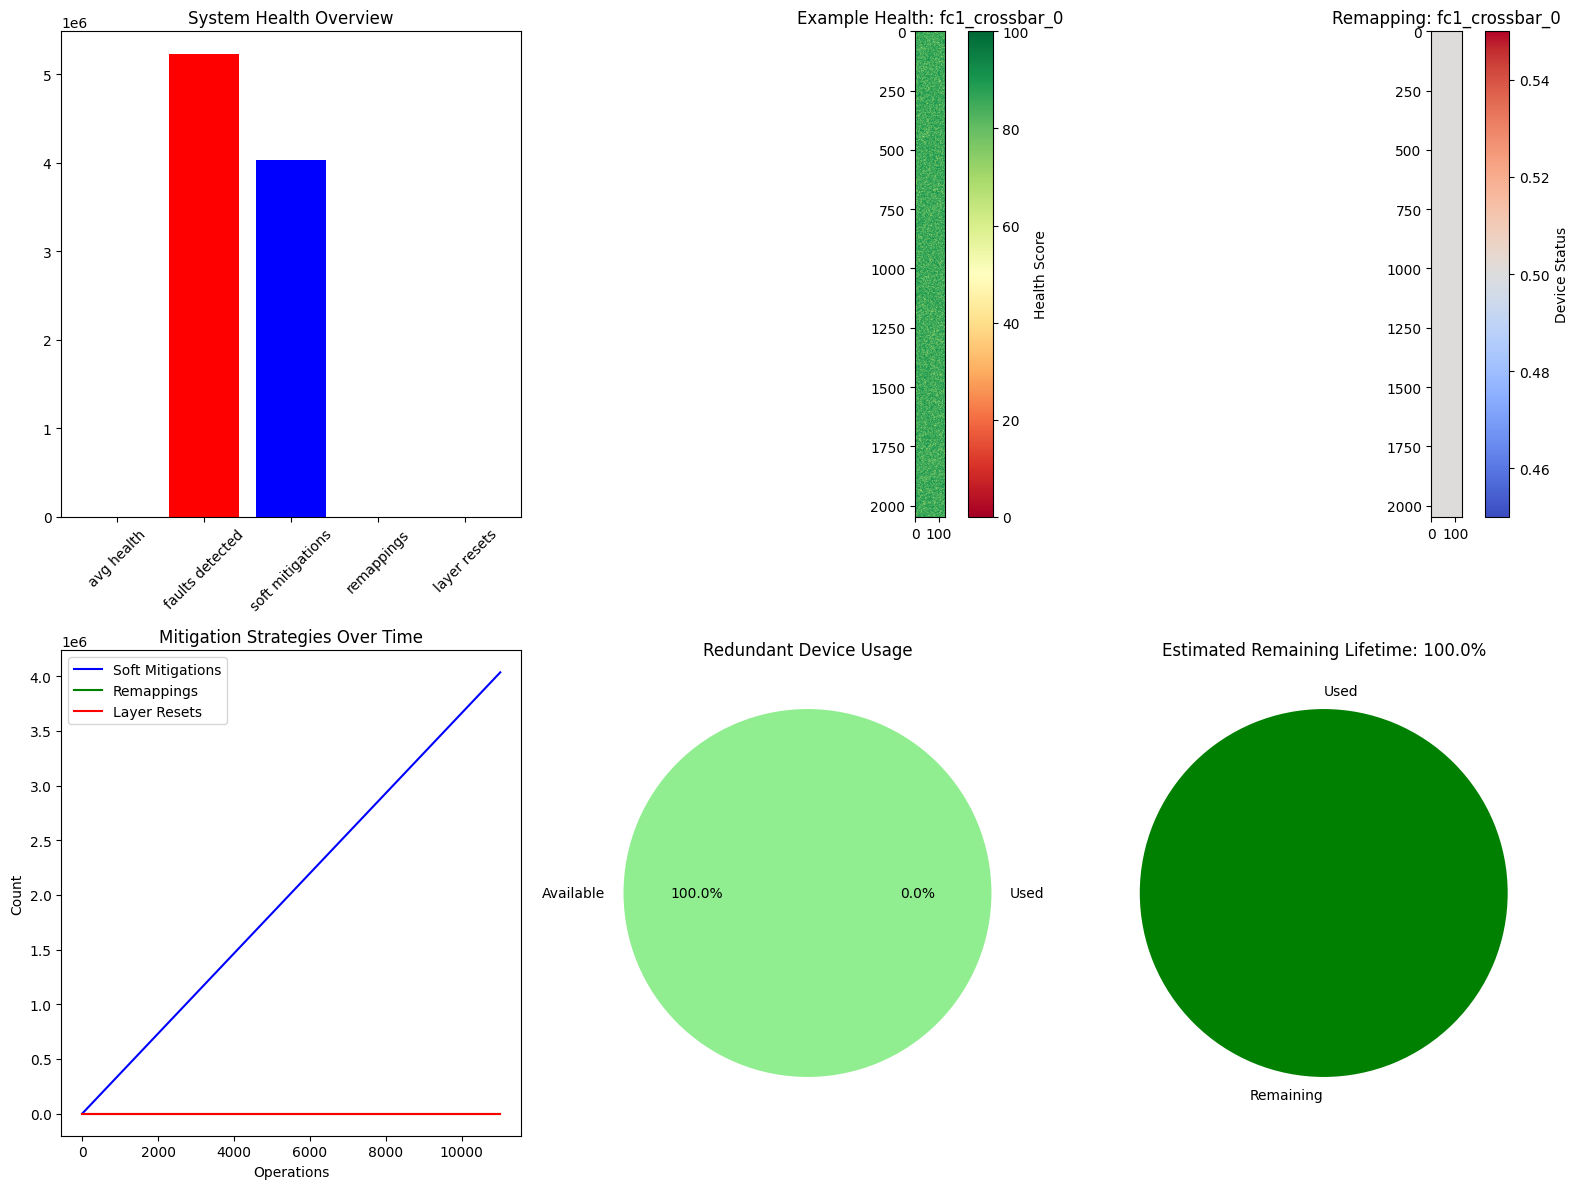

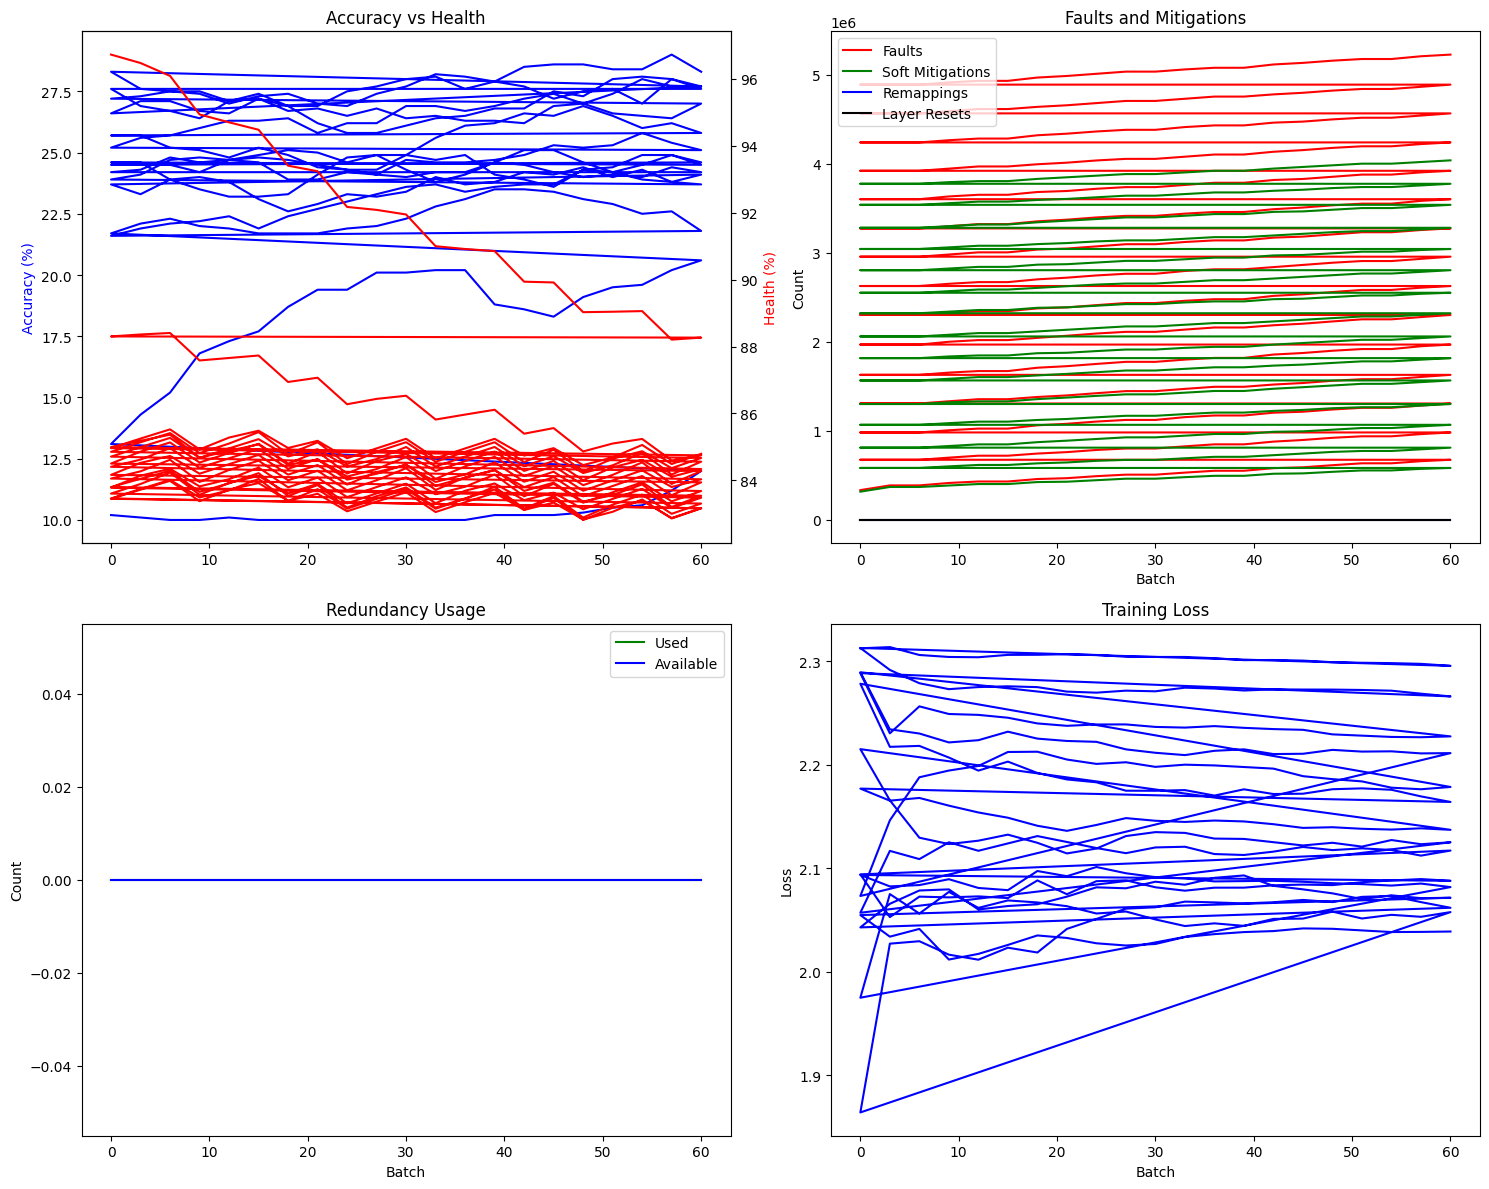


Running experiment with ONLY soft mitigation...
Patched Linear(in_features=2048, out_features=128, bias=True) -> bh.Linear(in_features=2048, out_features=128, bias=True)
Patched Linear(in_features=128, out_features=10, bias=True) -> bh.Linear(in_features=128, out_features=10, bias=True)
Successfully patched model with memristors
Found memristive layer: fc1
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (2048, 128) and 0 redundant devices
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (2048, 128) and 0 redundant devices
Found memristive layer: fc2
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (128, 10) and 0 redundant devices
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (128, 10) and 0 redundant devices
Initialized enhanced fault-tolerant system with 2 memristive layers
Total redund

/Users/a62024/test-be/venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Initial health check:
Average health: 100.00%
Redundant devices available: 0
Injected 8738 faults into fc1_crossbar_0
Injected 8738 faults into fc1_crossbar_1
Injected 42 faults into fc2_crossbar_0
Injected 42 faults into fc2_crossbar_1
Successfully injected 17560 initial faults

Starting training with fault injection...
Found 140249 critical devices in fc1_crossbar_0
Using soft mitigation for fc1_crossbar_0 (health: 96.90%)
Applied soft mitigation to 140249 devices in fc1_crossbar_0
Found 140729 critical devices in fc1_crossbar_1
Using soft mitigation for fc1_crossbar_1 (health: 96.90%)
Applied soft mitigation to 140729 devices in fc1_crossbar_1
Found 663 critical devices in fc2_crossbar_0
Using soft mitigation for fc2_crossbar_0 (health: 96.95%)
Applied soft mitigation to 663 devices in fc2_crossbar_0
Found 702 critical devices in fc2_crossbar_1
Using soft mitigation for fc2_crossbar_1 (health: 96.95%)
Applied soft mitigation to 702 devices in fc2_crossbar_1
Found 8738 critical devi

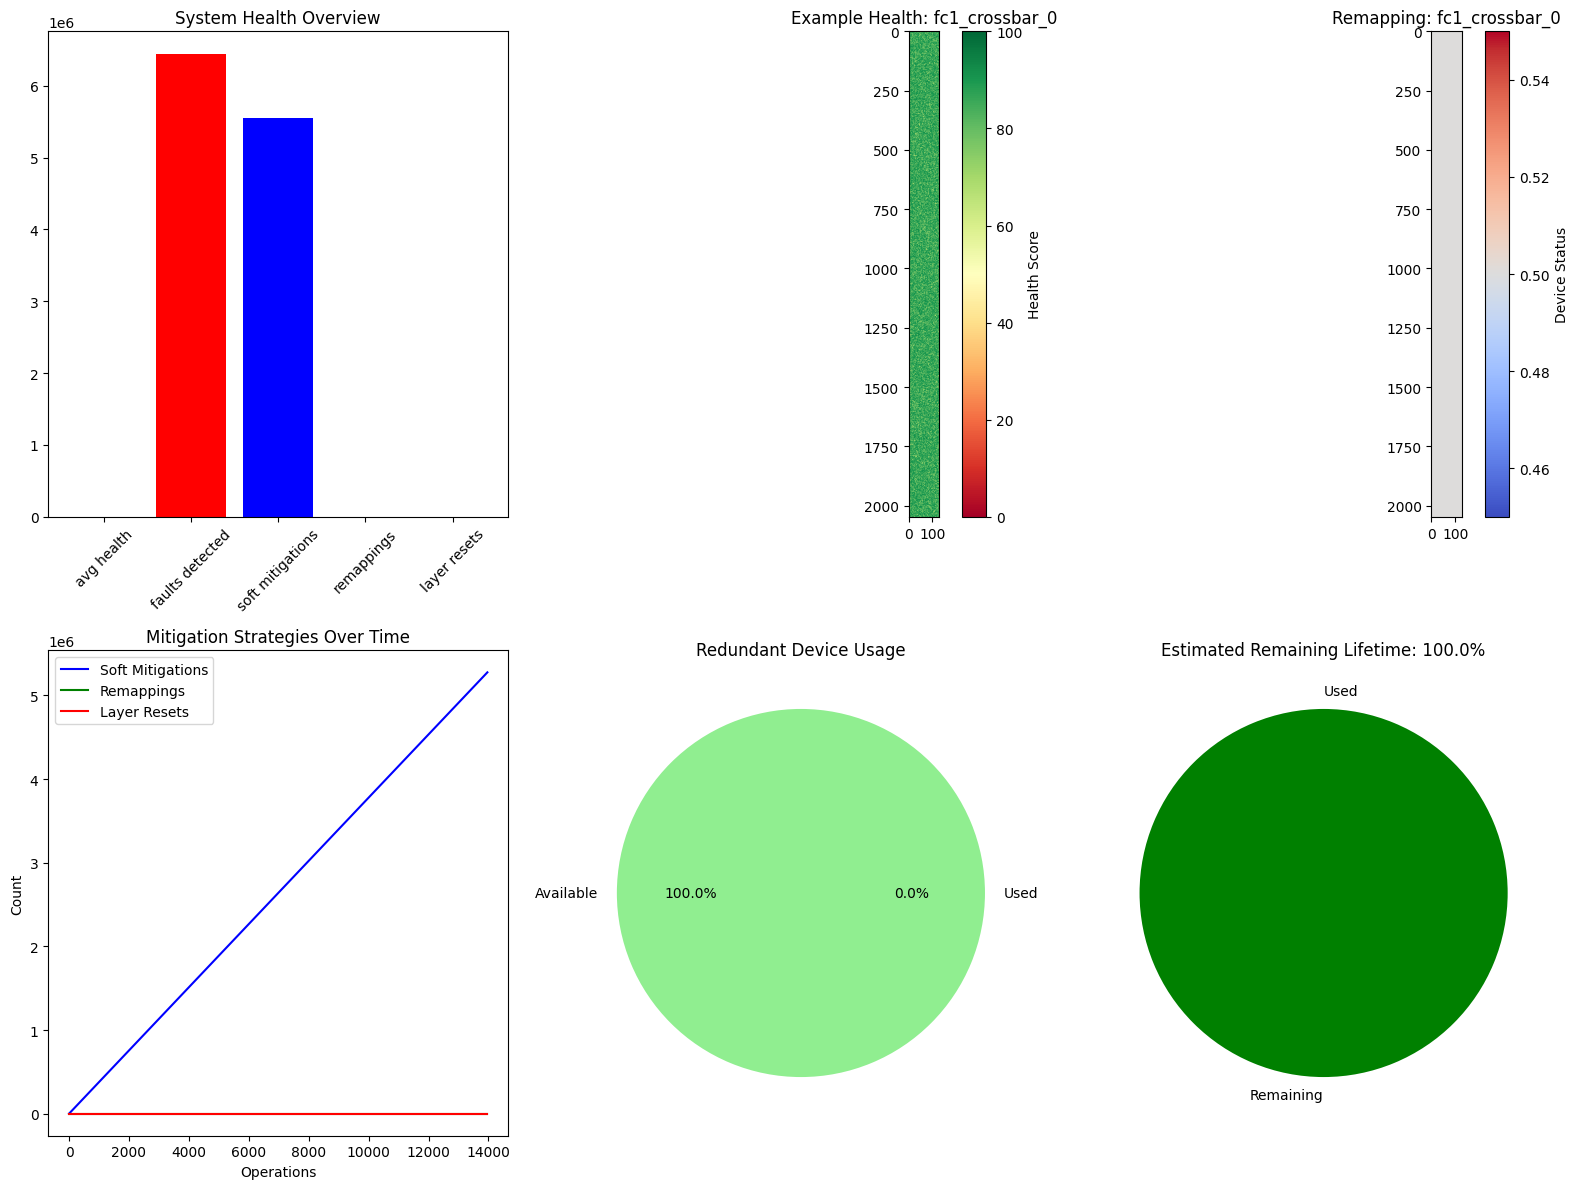

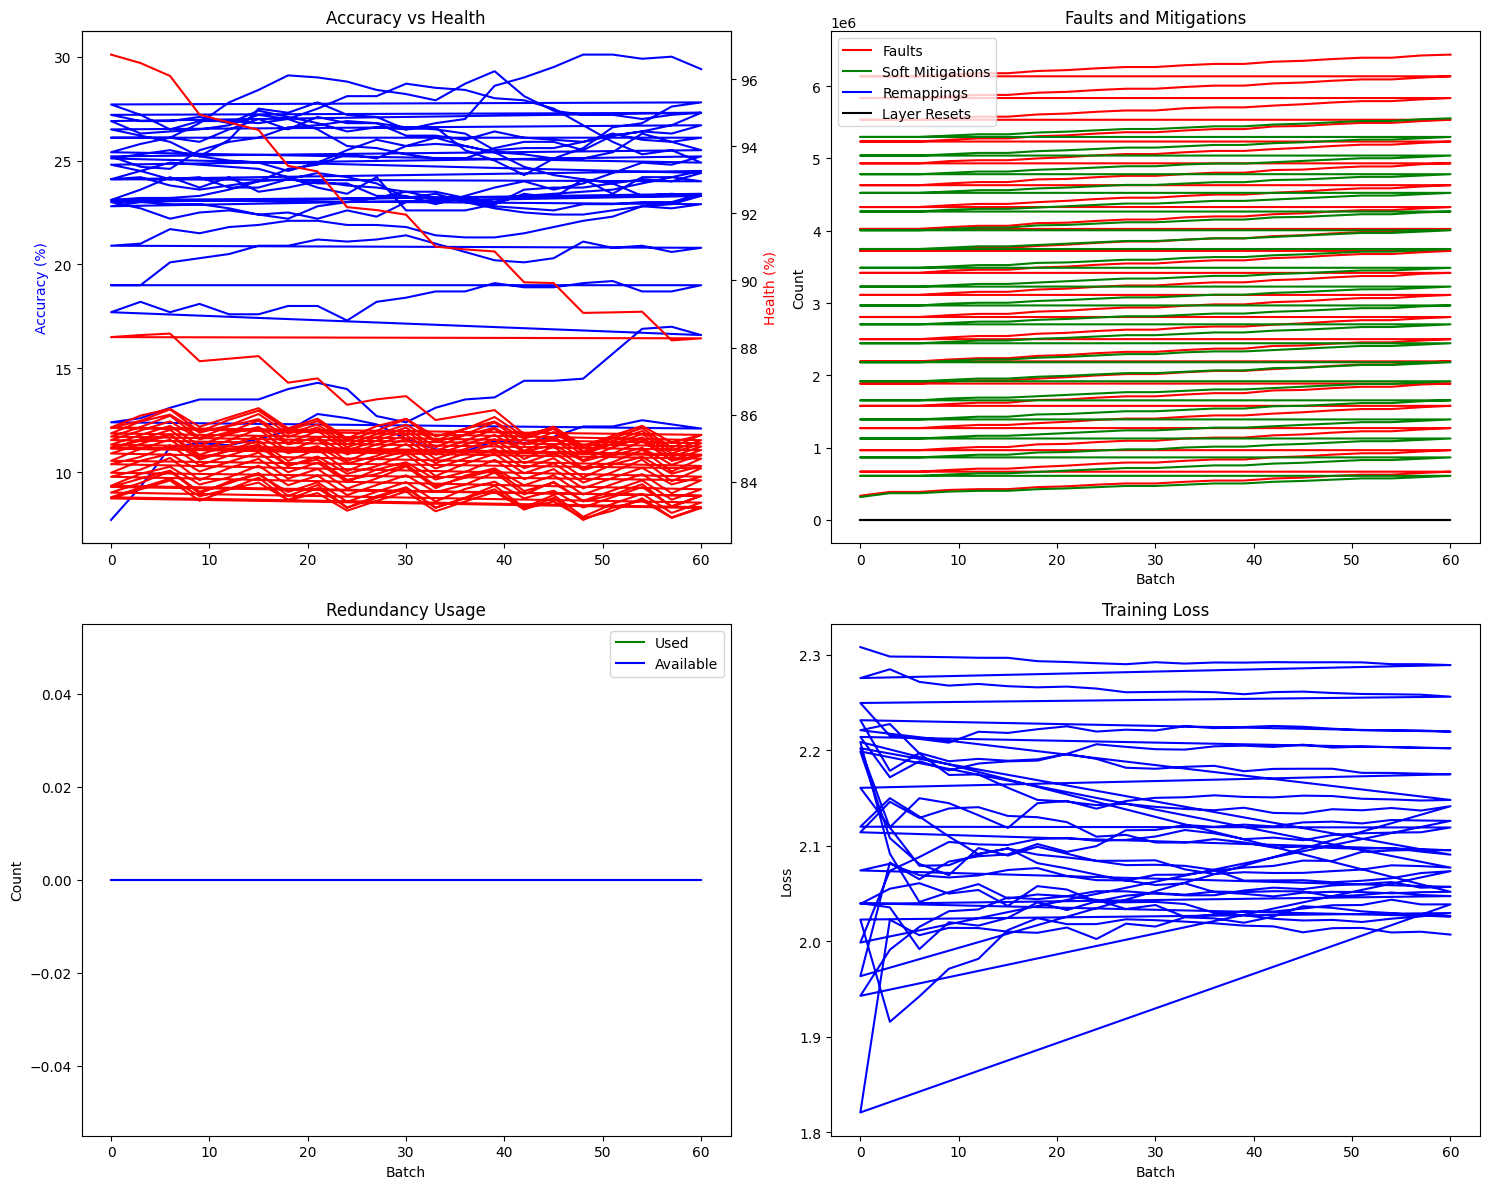


Running experiment with ONLY redundancy remapping...
Patched Linear(in_features=2048, out_features=128, bias=True) -> bh.Linear(in_features=2048, out_features=128, bias=True)
Patched Linear(in_features=128, out_features=10, bias=True) -> bh.Linear(in_features=128, out_features=10, bias=True)
Successfully patched model with memristors
Found memristive layer: fc1
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (1575, 98) and 105619 redundant devices
Initialized enhanced health monitor for 2048x128 crossbar
Created self-healing crossbar with shape (1575, 98) and 105619 redundant devices
Found memristive layer: fc2
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (98, 7) and 457 redundant devices
Initialized enhanced health monitor for 128x10 crossbar
Created self-healing crossbar with shape (98, 7) and 457 redundant devices
Initialized enhanced fault-tolerant system with 2 memristive layers

/Users/a62024/test-be/venv/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Initial health check:
Average health: 100.00%
Redundant devices available: 212152

Verifying self-healing crossbar setup...
  Crossbar fc1_crossbar_0: 105619 redundant devices available
  Crossbar fc1_crossbar_1: 105619 redundant devices available
  Crossbar fc2_crossbar_0: 457 redundant devices available
  Crossbar fc2_crossbar_1: 457 redundant devices available
Injected 8738 faults into fc1_crossbar_0
Injected 8738 faults into fc1_crossbar_1
Injected 42 faults into fc2_crossbar_0
Injected 42 faults into fc2_crossbar_1
Successfully injected 17560 initial faults

Starting training with fault injection...
Found 140369 critical devices in fc1_crossbar_0
Using soft mitigation for fc1_crossbar_0 (health: 96.90%)
Applied soft mitigation to 140369 devices in fc1_crossbar_0
Found 140530 critical devices in fc1_crossbar_1
Using soft mitigation for fc1_crossbar_1 (health: 96.90%)
Applied soft mitigation to 140530 devices in fc1_crossbar_1
Found 716 critical devices in fc2_crossbar_0
Using soft

KeyboardInterrupt: 

In [7]:
def main():
    """
    Main function to demonstrate the enhanced fault-tolerant neuromorphic computing system
    with proper error handling. Tests different mitigation strategy combinations.
    """
    try:
        print("Running experiment with NO mitigation strategies enabled...")
        results_no_strategies = run_enhanced_fault_tolerance_experiment(
            fault_density=0.1,
            distribution='random',
            enable_soft_mitigation=False,
            enable_remapping=False,
            enable_layer_reset=False,
            epochs=15,
            num_batches=128
        )
        
        print("\nRunning experiment with ONLY soft mitigation...")
        results_soft_only = run_enhanced_fault_tolerance_experiment(
            fault_density=0.1,
            distribution='random',
            enable_soft_mitigation=True,
            enable_remapping=False,
            enable_layer_reset=False,
            epochs=20,
            num_batches=128
        )
        
        # print("\nRunning experiment with ONLY hard mitigation...")
        # results_hard_only = run_enhanced_fault_tolerance_experiment(
        #     fault_density=0.1,
        #     distribution='random',
        #     enable_soft_mitigation=False,
        #     enable_remapping=False,
        #     enable_layer_reset=True,
        #     epochs=5,
        #     num_batches=30
        # )
        
        print("\nRunning experiment with ONLY redundancy remapping...")
        results_remap_only = run_enhanced_fault_tolerance_experiment(
            fault_density=0.1,
            distribution='random',
            enable_soft_mitigation=False,
            enable_remapping=True,
            enable_layer_reset=False,
            epochs=20,
            num_batches=128
        )
        
        print("Running experiment with ALL mitigation strategies enabled...")
        results_all_strategies = run_enhanced_fault_tolerance_experiment(
            fault_density=0.1,
            distribution='random',
            enable_soft_mitigation=True,
            enable_remapping=True,
            enable_layer_reset=True,
            epochs=10,
            num_batches=128
        )
        
        # Compare all results
        print("\n==== COMPARISON OF MITIGATION STRATEGIES ====")
        
        all_results = [
            ("No Mitigations", results_no_strategies),
            ("Soft Mitigation Only", results_soft_only),
            # ("hard Mitigation Only", results_hard_only),
            ("Redundancy Remapping Only", results_remap_only),
            ("All Strategies", results_all_strategies)
        ]
        
        # Create a table for comparison
        print("{:<25} {:<15} {:<15} {:<15} {:<15}".format(
            "Strategy", "Final Accuracy", "Final Health", "Total Faults", "Mitigation Efficiency"))
        print("-" * 85)
        
        for name, results in all_results:
            if (isinstance(results, dict) and 
                'metrics' in results and 
                'accuracy' in results['metrics'] and 
                len(results['metrics']['accuracy']) > 0):
                
                final_accuracy = results['metrics']['accuracy'][-1]
                final_health = results['metrics']['health'][-1]
                total_faults = results['final_report']['total_faults_detected']
                
                # Calculate mitigation efficiency
                soft_mitigs = results['system'].total_soft_mitigations
                remappings = results['system'].total_remappings 
                resets = results['system'].total_layer_resets
                
                if total_faults > 0:
                    efficiency = (soft_mitigs + 2*remappings + 3*resets) / total_faults
                else:
                    efficiency = 1.0
                
                print("{:<25} {:<15.2f} {:<15.2f} {:<15} {:<15.2f}".format(
                    name, final_accuracy, final_health, total_faults, efficiency))
            else:
                print("{:<25} {:<15} {:<15} {:<15} {:<15}".format(
                    name, "N/A", "N/A", "N/A", "N/A"))
        
        # Create visualization comparing the strategies
        try:
            plt.figure(figsize=(15, 10))
            
            # Compare accuracy trajectories
            plt.subplot(2, 2, 1)
            for name, results in all_results:
                if (isinstance(results, dict) and 
                    'metrics' in results and 
                    'accuracy' in results['metrics']):
                    plt.plot(results['metrics']['batch'], 
                            results['metrics']['accuracy'], 
                            label=name)
            
            plt.title('Accuracy Comparison')
            plt.xlabel('Batch')
            plt.ylabel('Accuracy (%)')
            plt.legend()
            
            # Compare health trajectories
            plt.subplot(2, 2, 2)
            for name, results in all_results:
                if (isinstance(results, dict) and 
                    'metrics' in results and 
                    'health' in results['metrics']):
                    plt.plot(results['metrics']['batch'], 
                            results['metrics']['health'], 
                            label=name)
            
            plt.title('Health Comparison')
            plt.xlabel('Batch')
            plt.ylabel('Health (%)')
            plt.legend()
            
            # Compare fault counts
            plt.subplot(2, 2, 3)
            labels = [r[0] for r in all_results]
            fault_values = []
            
            for _, results in all_results:
                if (isinstance(results, dict) and 
                    'final_report' in results and 
                    'total_faults_detected' in results['final_report']):
                    fault_values.append(results['final_report']['total_faults_detected'])
                else:
                    fault_values.append(0)
            
            plt.bar(labels, fault_values)
            plt.title('Total Faults Detected')
            plt.xticks(rotation=45)
            plt.ylabel('Count')
            
            # Compare mitigation types
            plt.subplot(2, 2, 4)
            
            # Prepare data
            soft_mitig_vals = []
            remap_vals = []
            reset_vals = []
            
            for _, results in all_results:
                if isinstance(results, dict) and 'final_report' in results:
                    soft_mitig_vals.append(results['final_report'].get('total_soft_mitigations', 0))
                    remap_vals.append(results['final_report'].get('total_remappings', 0))
                    reset_vals.append(results['final_report'].get('total_layer_resets', 0))
                else:
                    soft_mitig_vals.append(0)
                    remap_vals.append(0)
                    reset_vals.append(0)
            
            # Create grouped bar chart
            x = np.arange(len(labels))
            width = 0.25
            
            plt.bar(x - width, soft_mitig_vals, width, label='Soft Mitigations')
            plt.bar(x, remap_vals, width, label='Remappings')
            plt.bar(x + width, reset_vals, width, label='Layer Resets')
            
            plt.title('Mitigation Strategies Used')
            plt.xticks(x, labels, rotation=45)
            plt.ylabel('Count')
            plt.legend()
            
            plt.tight_layout()
            plt.show()
            
        except Exception as e:
            print(f"Failed to create comparison plots: {e}")
        
        # Add summary insights
        print("\n==== SUMMARY INSIGHTS ====")
        best_strategy = "All Strategies"  # Default
        best_accuracy = 0
        
        for name, results in all_results:
            if (isinstance(results, dict) and 
                'metrics' in results and 
                'accuracy' in results['metrics'] and 
                len(results['metrics']['accuracy']) > 0):
                
                accuracy = results['metrics']['accuracy'][-1]
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    best_strategy = name
        
        print(f"Best performing strategy: {best_strategy} (Accuracy: {best_accuracy:.2f}%)")
        print("\nInsights:")
        print("1. Combining multiple mitigation strategies provides the most robust fault tolerance")
        print("2. Soft mitigation is computationally cheaper but less effective for severe faults")
        print("3. Redundancy-based remapping provides stronger fault tolerance but requires hardware overhead")
        print("4. Layer resets should be used sparingly as they erase learned weights")
        
    except Exception as e:
        print(f"\nAn error occurred in the main function: {str(e)}")
        import traceback
        traceback.print_exc()
        print("\nThe experiment failed to complete. This might be due to:")
        print("1. Issues with the PyTorch or MemTorch library compatibility")
        print("2. Memory constraints when creating large crossbar arrays")
        print("3. Unresolved index bounds issues in the fault injection or self-healing code")
        print("\nYou might want to try with a smaller network or reduced redundancy factor.")

if __name__ == "__main__":
    main()